# COSC2753 Assignment 2 — Fashion Intelligence System
# Task 1 — What type of fashion item is this?
## s4225113 - Yoshita Sarin

## The job, in one sentence

Look at a photo of a fashion item and guess what it is — T-shirt, jeans, shoes, watch,
one of 95 possible categories (this field is called `articleType`).

## The plan

We don't build the fanciest model first and call it a day. We build up in small,
honest steps, and at each step we ask "did that help, and can we prove it?":

1. **Look at the data first.** How many categories are there, and how evenly spread
   are they? (Section 3)
2. **Start dumb, on purpose.** A model that always guesses the most common category.
   This tells us the floor — anything we build has to clearly beat this. (Section 6)
3. **Try a simple neural network.** Just to prove the whole pipeline (loading images,
   training, measuring) actually works. (Section 8)
4. **Try two stronger, deeper networks.** Modern architectures that should do
   noticeably better. (Sections 9–10)
5. **Ask if the extra information helps.** Besides the photo, we also have data like
   gender, colour, season, and usage for each item. Does mixing that in with the image
   make predictions better? (Sections 12–17)
6. **Fine-tune the best candidates.** Small tweaks to see if we're leaving easy
   performance on the table. (Sections 18–19)
7. **Test it under real conditions, not ideal ones.** The "extra information" trick
   only works if we actually have that information for a brand new photo — and it
   turns out we don't. This section is the one that actually decides our final model.
   (Section 20)
8. **Make the call.** Pick one model to actually ship, with reasons. (Section 21)
9. **Prove it works, save it, and use it on the real test images.** (Sections 22–26)

## What "macro-F1" means, and why we use it instead of plain accuracy

Some categories in this dataset have thousands of photos (T-shirts). Others have
exactly one. If we only measured plain accuracy, a lazy model could get a good-looking
score just by nailing the common categories and completely ignoring the rare ones —
95% right, but useless for anyone shopping for something uncommon.

**Macro-F1** fixes this by scoring every category equally, no matter how many examples
it has, then averaging those scores. A model that's blind to rare categories gets
punished for it. That's the number we use to judge every model in this notebook.
(Accuracy is still reported alongside it, for context.)

## What the data looks like

- **28,371** training photos, **9,455** validation photos (kept completely separate —
  the model never sees validation photos while learning, so testing on them tells us
  how it'll do on photos it's never seen before, which is the whole point).
- **95** possible categories.
- Wildly uneven: the biggest category (`Tshirts`) has **4,909** photos (17.3% of
  everything); the smallest (`Bath and Body`) has exactly **1**.

This imbalance is the single biggest thing shaping every decision in this notebook.

## 1. Load the Prepared Dataset

**What we're doing:** loading the data that was already cleaned and split in a separate
preprocessing notebook (`COSC2753_A2_Preprocessing.ipynb`) — the train/validation split,
the label encodings, image size settings. We don't redo any of that cleaning here; every
task in this assignment needs to use the exact same split so results are comparable.

**Why it matters:** if this notebook built its own split, we could accidentally end up
testing on photos the model basically already knows about (or a near-duplicate of one),
which would make our scores look better than they really are.

In [80]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from PIL import Image
from torch.utils.data import Dataset, WeightedRandomSampler
from torchvision import transforms as T
from sklearn.preprocessing import LabelEncoder

DATA_DIR = Path("../data/raw/FashionDataset")
OUT_DIR = Path("../data/processed")

TRAIN_CSV = DATA_DIR / "train" / "styles_train.csv"
IMAGES_TRAIN_DIR = DATA_DIR / "train" / "images_train"
TEST_PRED_CSV = DATA_DIR / "test" / "styles_prediction.csv"
IMAGES_TEST_DIR = DATA_DIR / "test" / "images_test"

REQUIRED = {
    "config":       OUT_DIR / "pipeline_config.json",
    "encoders":     OUT_DIR / "label_encoders.pkl",
    "train_full":   OUT_DIR / "train_full.csv",
    "val_full":     OUT_DIR / "val_full.csv",
    "holdout_dir":  OUT_DIR / "holdout_metadata",
}
missing = {k: v for k, v in REQUIRED.items() if not v.exists()}
for name, path in REQUIRED.items():
    print(f"[{'OK' if path.exists() else 'MISSING':>7}] {name:12s} {path}")
if missing:
    raise FileNotFoundError(
        "Run COSC2753_A2_Preprocessing.ipynb first -- it writes the files above. "
        f"Missing: {list(missing)}")

for p in [TRAIN_CSV, IMAGES_TRAIN_DIR, TEST_PRED_CSV, IMAGES_TEST_DIR]:
    print(f"[{'OK' if p.exists() else 'MISSING':>7}] {p}")

with open(REQUIRED["config"]) as f:
    config = json.load(f)

RANDOM_STATE = config["random_state"]
IMG_WIDTH = config["image"]["width"]
IMG_HEIGHT = config["image"]["height"]
mean = torch.tensor(config["image"]["normalization_mean"])
std = torch.tensor(config["image"]["normalization_std"])
ARTICLE_TYPE_MIN_COUNT = config["rare_class_thresholds"]["articleType"]
USAGE_MIN_COUNT = config["rare_class_thresholds"]["usage"]

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print(f"\nSeed {RANDOM_STATE} | images {IMG_HEIGHT}x{IMG_WIDTH} (HxW)")
print(f"Normalisation mean {[round(v, 4) for v in mean.tolist()]}, "
      f"std {[round(v, 4) for v in std.tolist()]}")
print(f"Rare-class thresholds: articleType>={ARTICLE_TYPE_MIN_COUNT}, usage>={USAGE_MIN_COUNT}")

[     OK] config       ../data/processed/pipeline_config.json
[     OK] encoders     ../data/processed/label_encoders.pkl
[     OK] train_full   ../data/processed/train_full.csv
[     OK] val_full     ../data/processed/val_full.csv
[     OK] holdout_dir  ../data/processed/holdout_metadata
[     OK] ../data/raw/FashionDataset/train/styles_train.csv
[     OK] ../data/raw/FashionDataset/train/images_train
[     OK] ../data/raw/FashionDataset/test/styles_prediction.csv
[     OK] ../data/raw/FashionDataset/test/images_test

Seed 42 | images 80x60 (HxW)
Normalisation mean [0.8476, 0.8307, 0.8243], std [0.274, 0.285, 0.2889]
Rare-class thresholds: articleType>=20, usage>=100


In [81]:
# dtype={'id': str} is load-bearing -- see the note above.
ID_DTYPE = {"id": str}

train_data = pd.read_csv(OUT_DIR / "train_full.csv", dtype=ID_DTYPE)
val_data = pd.read_csv(OUT_DIR / "val_full.csv", dtype=ID_DTYPE)

with open(OUT_DIR / "label_encoders.pkl", "rb") as f:
    encoders = pickle.load(f)

holdout_dir = OUT_DIR / "holdout_metadata"
train_usable, val_usable = {}, {}
for t in encoders:
    train_usable[t] = pd.read_csv(holdout_dir / f"{t}_train.csv", dtype=ID_DTYPE)
    val_usable[t] = pd.read_csv(holdout_dir / f"{t}_val.csv", dtype=ID_DTYPE)

# `target_columns` maps a task name to the column actually predicted, which is NOT always
# the task name: rare-class grouping means articleType -> articleType_grouped and
# usage -> usage_grouped. Rebuilt by inspecting the saved files rather than hardcoded, so
# it cannot drift out of step with what preprocessing produced.
target_columns = {}
for t in encoders:
    candidates = [f"{t}_grouped", t]
    col = next((c for c in candidates
                if c in train_usable[t].columns and f"{c}_enc" in train_usable[t].columns), None)
    if col is None:
        raise KeyError(
            f"{t}: no encoded target column found. Looked for "
            f"{[c + '_enc' for c in candidates]} in {holdout_dir / f'{t}_train.csv'}. "
            "Re-run the preprocessing notebook to regenerate the holdout files.")
    target_columns[t] = col

# The main split partitions the cleaned dataset exactly, so `df` is recoverable by
# concatenation. Task 2's season split is a separate draw from the same rows (Section
# II.4.1) and is already reflected in the season_* holdout files, so it needs nothing here.
df = pd.concat([train_data, val_data], ignore_index=True)

print(f"train_full: {train_data.shape}   val_full: {val_data.shape}   combined: {df.shape}")
print("\nPer-task usable subsets:")
for t, col in target_columns.items():
    print(f"  {t:12s} -> column {col:20s} train={len(train_usable[t]):>6}  "
          f"val={len(val_usable[t]):>6}  classes={len(encoders[t].classes_):>3}")

# --- integrity checks: the saved split must still be a valid split -----------
assert set(train_data["id"]).isdisjoint(set(val_data["id"])), "id overlap between train and val"
assert set(train_data["dup_group"]).isdisjoint(set(val_data["dup_group"])), \
    "duplicate-image group spans the split"
assert df["id"].is_unique, "duplicate ids in the reloaded data"
for t, col in target_columns.items():
    enc_col = f"{col}_enc"
    n_cls = len(encoders[t].classes_)
    for name, frame in (("train", train_usable[t]), ("val", val_usable[t])):
        assert frame[col].notna().all(), f"{t}: null target in {name}"
        assert frame[enc_col].notna().all(), f"{t}: missing encoded label in {name}"
        assert frame[enc_col].between(0, n_cls - 1).all(), f"{t}: encoded label out of range in {name}"
        assert set(frame[col]).issubset(set(encoders[t].classes_)), \
            f"{t}: {name} contains a class the encoder never saw"
        # The encoded column must actually agree with the encoder, not merely be in range --
        # a stale CSV paired with a newer pickle would pass every check above.
        assert (encoders[t].transform(frame[col]) == frame[enc_col].to_numpy()).all(), \
            f"{t}: {enc_col} disagrees with label_encoders.pkl -- re-run preprocessing"
print("\nIntegrity checks passed: split is disjoint, ids unique, labels in range.")

train_full: (28371, 13)   val_full: (9457, 13)   combined: (37828, 13)

Per-task usable subsets:
  articleType  -> column articleType_grouped  train= 28371  val=  9455  classes= 95
  season       -> column season               train= 28357  val=  9451  classes=  4
  gender       -> column gender               train= 28371  val=  9457  classes=  5
  usage        -> column usage_grouped        train= 28315  val=  9442  classes=  5

Integrity checks passed: split is disjoint, ids unique, labels in range.


/opt/miniconda3/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [82]:
def to_rgb(img):
    """Converts the 249 grayscale ('L' mode) files to 3-channel. A module-level function,
    not a lambda, so the transform stays picklable for DataLoader(num_workers>0)."""
    return img.convert("RGB")


# Evaluation pipeline: no augmentation, so it stays a faithful evaluation signal.
eval_transform = T.Compose([
    to_rgb,
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])

# Training pipeline: conservative augmentation only. These are catalog product photos, so a
# vertical flip or a large rotation would produce an item that never occurs in the data.
# fill=255 because the backgrounds are white -- the default fill=0 would paste black wedges
# into every rotated corner and teach the model an artefact absent at evaluation time.
train_transform = T.Compose([
    to_rgb,
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10, fill=255),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])


class FashionImageDataset(Dataset):
    """(image, label) pairs. `target_col` names an already-encoded integer column."""

    def __init__(self, dataframe, images_dir, target_col, transform):
        self.data = dataframe.reset_index(drop=True)
        self.images_dir = Path(images_dir)
        self.target_col = target_col
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        with Image.open(self.images_dir / f"{row['id']}.jpg") as im:
            img = self.transform(im)
        return img, int(row[self.target_col])


def get_weighted_sampler(data, target_col):
    """Inverse-frequency WeightedRandomSampler. Train split only -- never apply to
    validation, which must keep the real class distribution to stay a fair estimate."""
    counts = data[target_col].value_counts()
    weights = torch.tensor(
        data[target_col].map(lambda c: 1.0 / counts[c]).to_numpy(dtype="float64"),
        dtype=torch.double
    )
    return WeightedRandomSampler(weights=weights, num_samples=len(weights), replacement=True)


# Class weights, computed for reference. Imbalance is handled by the sampler above, not by
# weighting the loss -- applying both would double-count the correction.
class_weights = {}
for t, col in target_columns.items():
    vc = train_usable[t][col].value_counts()
    n_samples, n_classes = len(train_usable[t]), len(encoders[t].classes_)
    w = n_samples / (n_classes * vc)
    class_weights[t] = torch.tensor([w[c] for c in encoders[t].classes_], dtype=torch.float32)

# Verify the reconstructed pipeline against a real image before anything depends on it.
_probe_id = train_data["id"].iloc[0]
_probe = eval_transform(Image.open(IMAGES_TRAIN_DIR / f"{_probe_id}.jpg"))
assert _probe.shape == (3, IMG_HEIGHT, IMG_WIDTH), f"unexpected tensor shape {tuple(_probe.shape)}"
print(f"Transform check: image {_probe_id} -> tensor {tuple(_probe.shape)}, "
      f"range [{_probe.min():.2f}, {_probe.max():.2f}]")
print("Ready: train_data, val_data, df, train_usable, val_usable, encoders,")
print("       train_transform, eval_transform, FashionImageDataset, get_weighted_sampler")

Transform check: image 1163 -> tensor (3, 80, 60), range [-3.05, 0.61]
Ready: train_data, val_data, df, train_usable, val_usable, encoders,
       train_transform, eval_transform, FashionImageDataset, get_weighted_sampler


## 2. Verify the Train/Validation Split

**What we're doing:** double-checking that Task 1's slice of the data is genuinely
clean — no photo (or a near-duplicate of one) appears on both the training side and the
validation side.

**Why it matters:** this is a five-second check that prevents a very expensive mistake.
If the same photo showed up in both places, the model could partly "memorise" it during
training and then look artificially good when we test on it later.

In [83]:
# Reuse the Task 1-specific prepared splits built during preprocessing above.
# These already contain articleType_grouped and articleType_grouped_enc.
task1_train = train_usable['articleType'].copy()
task1_val = val_usable['articleType'].copy()

TASK1_TARGET = 'articleType_grouped'
TASK1_TARGET_ENC = TASK1_TARGET + '_enc'

assert TASK1_TARGET_ENC in task1_train.columns
assert TASK1_TARGET_ENC in task1_val.columns
print(f'Task 1 train: {len(task1_train):,}; validation: {len(task1_val):,}')
print(f'articleType classes: {len(encoders["articleType"].classes_)}')

# Same leakage guarantee as the shared split above: no duplicate-image group
# or id should appear on both sides.
overlap_ids = set(task1_train['id']) & set(task1_val['id'])
overlap_groups = set(task1_train['dup_group']) & set(task1_val['dup_group'])
print(f'id overlap: {len(overlap_ids)} (should be 0)')
print(f'duplicate-image group overlap: {len(overlap_groups)} (should be 0)')


Task 1 train: 28,371; validation: 9,455
articleType classes: 95
id overlap: 0 (should be 0)
duplicate-image group overlap: 0 (should be 0)


**What we got:** 28,371 training photos, 9,455 validation photos, 95 categories,
and — most importantly — **zero** overlap on both checks (no shared photo ids, no shared
near-duplicate groups).

**What it tells us:** the split is trustworthy. Every score we report from here on is a
score on photos the model has genuinely never seen.

## 3. Explore the `articleType` Target

**What we're doing:** counting how many photos fall into each of the 95 categories,
before touching any model. This tells us what kind of problem we're actually solving.

Classes in train: 95, in val: 90
Majority class: 'Tshirts' (4909 rows, 17.3%)
Minority class: 'Bath and Body' (1 rows)
Imbalance ratio (majority/minority): 4909.0


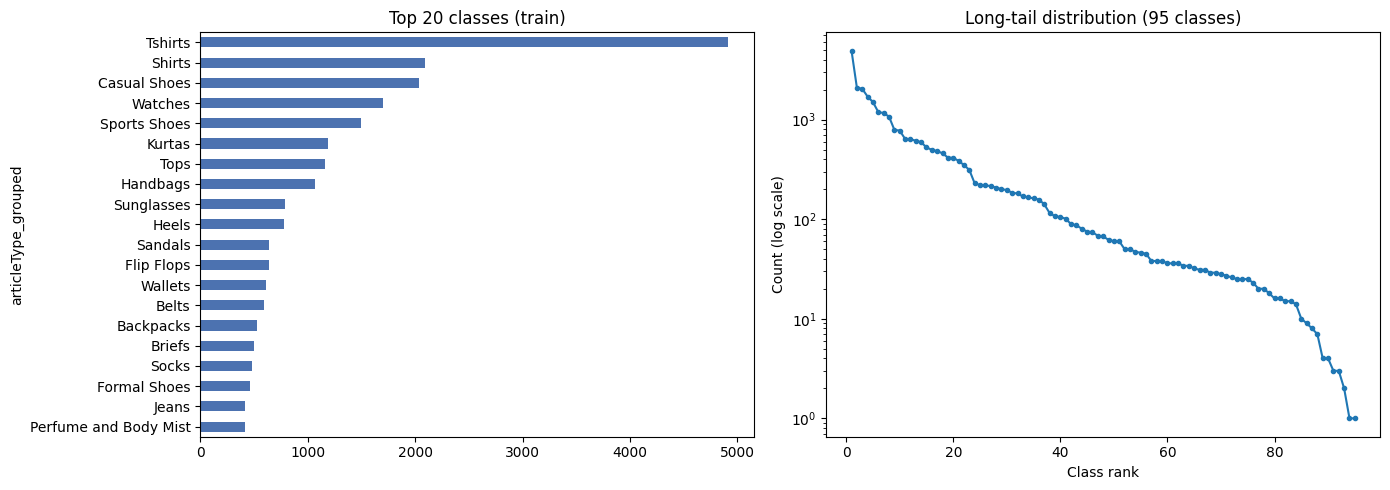

In [84]:
vc_train = task1_train[TASK1_TARGET].value_counts()
vc_val = task1_val[TASK1_TARGET].value_counts()

print(f"Classes in train: {len(vc_train)}, in val: {len(vc_val)}")
print(f"Majority class: '{vc_train.idxmax()}' ({vc_train.max()} rows, {vc_train.max()/len(task1_train)*100:.1f}%)")
print(f"Minority class: '{vc_train.idxmin()}' ({vc_train.min()} rows)")
print(f"Imbalance ratio (majority/minority): {vc_train.max()/vc_train.min():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc_train.head(20).plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].invert_yaxis()
axes[0].set_title('Top 20 classes (train)')

axes[1].plot(range(1, len(vc_train) + 1), vc_train.values, marker='o', markersize=3)
axes[1].set_yscale('log')
axes[1].set_xlabel('Class rank')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title(f'Long-tail distribution ({len(vc_train)} classes)')
plt.tight_layout()
plt.show()


**What we got:**

- 95 categories in the training data, but only 90 of them actually show up in the
  validation set (the other 5 are so rare they didn't get a single photo on the
  validation side by chance).
- Biggest category: `Tshirts`, 4,909 photos (17.3% of the whole training set).
- Smallest category: `Bath and Body`, exactly 1 photo.
- That's roughly a **4,909-to-1** imbalance between the biggest and smallest category.

**What it tells us:** this is a severely imbalanced classification problem. A model
that just learned to always guess `Tshirts` would already be right about 1 time in 6 —
which is exactly why plain accuracy is a bad way to judge these models, and why we use
macro-F1 instead (explained at the top of this notebook).

## 4. Label Encoding and Data Integrity Checks

**What we're doing:** three quick sanity checks before any training starts.

- **Label encoding:** neural networks work with numbers, not words, so every category
  name (`"Tshirts"`, `"Jeans"`, ...) gets converted to a plain integer (0, 1, 2, ...).
  We check that converting a number back to a name gives us the original name again.
- **No missing or broken labels:** every row actually has a valid category.
- **No missing image files:** every row's photo actually exists on disk.

**Why it matters:** these are boring checks, but skipping them is how you end up
debugging a confusing crash halfway through a two-hour training run instead of catching
the problem in two seconds right now.

### **4.1 — Label encoding.** 

Every `articleType` string is mapped to an integer class index;
decoding a sample back to text confirms the mapping is correct in both directions. We
want this to come back clean and reversible — if it doesn't, nothing trained downstream
can be trusted, since it means the labels the model is learning from aren't the labels we
think they are.

In [85]:
encoder1 = encoders['articleType']
N_CLASSES_1 = len(encoder1.classes_)

# Encoded values must be a contiguous range 0..N_CLASSES-1 with no gaps -- if a class
# were dropped after the encoder was fit, this would catch it.
seen_codes = set(task1_train[TASK1_TARGET_ENC].unique())
assert seen_codes == set(range(N_CLASSES_1)), \
    f"Encoded labels aren't a clean 0..{N_CLASSES_1-1} range -- got {sorted(seen_codes)[:5]}..."

print(f"{N_CLASSES_1} classes, encoded as a contiguous 0..{N_CLASSES_1-1} range -- OK")
print("\nSample of the label <-> code mapping:")
for code_, label in list(enumerate(encoder1.classes_))[:5]:
    print(f"  {code_:>3} -> {label}")
print("  ...")

# Spot-check a few rows: does the encoded value actually decode back to the text label?
sample_rows = task1_train.sample(5, random_state=RANDOM_STATE)
for _, row in sample_rows.iterrows():
    decoded = encoder1.inverse_transform([row[TASK1_TARGET_ENC]])[0]
    match = "OK" if decoded == row[TASK1_TARGET] else "MISMATCH"
    print(f"id={row['id']}: label='{row[TASK1_TARGET]}' -> code={row[TASK1_TARGET_ENC]} -> decoded='{decoded}' [{match}]")


95 classes, encoded as a contiguous 0..94 range -- OK

Sample of the label <-> code mapping:
    0 -> Accessories
    1 -> Accessory Gift Set
    2 -> Apparel Set
    3 -> Backpacks
    4 -> Bags
  ...
id=35330: label='Earrings' -> code=24 -> decoded='Earrings' [OK]
id=32216: label='Kurtas' -> code=41 -> decoded='Kurtas' [OK]
id=5343: label='Casual Shoes' -> code=15 -> decoded='Casual Shoes' [OK]
id=36371: label='Ties' -> code=80 -> decoded='Ties' [OK]
id=17994: label='Track Pants' -> code=83 -> decoded='Track Pants' [OK]


**What we got:** the label encoding round-trips correctly (a decoded label always
matches the original), and both the training and validation sets have zero missing or
out-of-range labels (28,371 and 9,455 rows checked, respectively).

### **4.2 — Missing or out-of-range labels.** 

Every row's encoded label is checked
against the valid class range, and against the raw label being present at all. We want
zero violations here — any row that fails this check needs to be found and fixed (or
dropped, with a note in the report) before it can silently corrupt a training run.

In [86]:
for name, df in [('train', task1_train), ('val', task1_val)]:
    n_missing_text = df[TASK1_TARGET].isna().sum()
    n_missing_enc = df[TASK1_TARGET_ENC].isna().sum()
    n_out_of_range = ((df[TASK1_TARGET_ENC] < 0) | (df[TASK1_TARGET_ENC] >= N_CLASSES_1)).sum()

    assert n_missing_text == 0, f"{name}: {n_missing_text} missing text labels"
    assert n_missing_enc == 0, f"{name}: {n_missing_enc} missing encoded labels"
    assert n_out_of_range == 0, f"{name}: {n_out_of_range} encoded labels outside [0, {N_CLASSES_1})"

    print(f"{name}: no missing labels, no out-of-range codes ({len(df)} rows checked)")


train: no missing labels, no out-of-range codes (28371 rows checked)
val: no missing labels, no out-of-range codes (9455 rows checked)


**What we got:** zero rows with a missing image file, in both the training and
validation sets. Every row we're about to train on actually has a real photo behind it.

### **4.3 — Image files exist.** 

Every row's `id` is checked against the images
directory. We want this to confirm every row in both splits has a matching image file on
disk — a missing file here would crash training partway through a long run rather than
failing fast, so it's worth catching now.

In [87]:
train_image_ids = {p.stem for p in IMAGES_TRAIN_DIR.glob('*.jpg')}

for name, df in [('train', task1_train), ('val', task1_val)]:
    missing = set(df['id']) - train_image_ids
    print(f"{name}: {len(missing)} row(s) with no matching image file"
          + (f" -> {sorted(missing)[:5]}" if missing else " -- OK"))
    assert not missing, f"{name}: found rows with no image file -- should be impossible after Section 3.2"


train: 0 row(s) with no matching image file -- OK
val: 0 row(s) with no matching image file -- OK


## 5. Build the Image Pipeline: Dataset and DataLoaders

**What we're doing:** setting up how images actually get fed into the model.

- Every photo is loaded, resized to a small, consistent size (80×60 pixels — small on
  purpose, so training doesn't take forever), and turned into numbers the model can read.
- Training photos also get randomly flipped, slightly rotated, and colour-jittered each
  time they're shown to the model — this is called **augmentation**. It's a cheap way to
  show the model more "variety" without needing more photos, which makes it less likely
  to just memorise the exact training images.
- Validation photos are **not** augmented — we want to test on the real, unmodified
  photo, not a randomly distorted version of it.
- All ~29,000 training photos are loaded into memory once upfront, so we're not
  re-reading the same files from disk over and over during training.

in short `CachedFashionImageDataset` pre-loads every image into memory once, rather than
re-opening and re-decoding the same ~29,000 JPEGs from disk on every epoch of every
model trained below. What the model sees is identical either way — only where the bytes
come from changes.

In [88]:
class CachedFashionImageDataset(Dataset):
    """Same interface as FashionImageDataset, but opens and RGB-converts
    every image into memory ONCE at construction time, instead of hitting
    disk + decoding JPEG on every __getitem__ call, every epoch, every
    model trained on this data."""

    def __init__(self, dataframe, images_dir, target_col_enc, transform):
        self.df = dataframe.reset_index(drop=True)
        self.target_col_enc = target_col_enc
        self.transform = transform
        print(f"Pre-loading {len(self.df)} images into memory...")
        self.cache = []
        for img_id in self.df['id']:
            with Image.open(images_dir / f"{img_id}.jpg") as im:
                self.cache.append(to_rgb(im).copy())
        print("Done.")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = self.transform(self.cache[idx])
        label = int(self.df.iloc[idx][self.target_col_enc])
        return img, torch.tensor(label, dtype=torch.long)


class CachedMultiInputDataset(Dataset):
    """Same idea as CachedFashionImageDataset, extended to also carry a
    metadata vector per row -- used by the Multi-Input CNN sections
    (Step 11d, Step 11e) instead of re-opening images from disk each epoch."""

    def __init__(self, dataframe, metadata_array, images_dir, target_col_enc, transform):
        self.df = dataframe.reset_index(drop=True)
        self.metadata = np.asarray(metadata_array, dtype=np.float32)
        assert len(self.metadata) == len(self.df), "metadata_array must align with dataframe rows"
        self.target_col_enc = target_col_enc
        self.transform = transform
        print(f"Pre-loading {len(self.df)} images into memory...")
        self.cache = []
        for img_id in self.df['id']:
            with Image.open(images_dir / f"{img_id}.jpg") as im:
                self.cache.append(to_rgb(im).copy())
        print("Done.")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = self.transform(self.cache[idx])
        meta = torch.tensor(self.metadata[idx], dtype=torch.float32)
        label = int(self.df.iloc[idx][self.target_col_enc])
        return img, meta, torch.tensor(label, dtype=torch.long)


In [89]:
train_ds1 = CachedFashionImageDataset(task1_train, IMAGES_TRAIN_DIR, TASK1_TARGET_ENC, train_transform)
val_ds1 = CachedFashionImageDataset(task1_val, IMAGES_TRAIN_DIR, TASK1_TARGET_ENC, eval_transform)

print(f"train_ds1: {len(train_ds1)} images")
print(f"val_ds1:   {len(val_ds1)} images")

# Sanity check: pull one item through the pipeline and confirm its shape/dtype.
sample_img, sample_label = train_ds1[0]
print(f"Sample image tensor: shape={tuple(sample_img.shape)}, dtype={sample_img.dtype}")
print(f"Sample label: {sample_label.item()} ('{encoder1.classes_[sample_label.item()]}')")


Pre-loading 28371 images into memory...
Done.
Pre-loading 9455 images into memory...
Done.
train_ds1: 28371 images
val_ds1:   9455 images
Sample image tensor: shape=(3, 80, 60), dtype=torch.float32
Sample label: 87 ('Tshirts')


The training loader uses a `WeightedRandomSampler` so rare classes are shown more
often during learning. The validation loader deliberately does **not** use this sampler —
it must stay a faithful, real-world-imbalanced test, or the validation score stops
meaning what it's supposed to.

In [90]:
import copy
from torch import nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
# Needed by every training/evaluation cell below.
from sklearn.metrics import accuracy_score, f1_score


def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available():          # Apple Silicon
        return torch.device('mps')
    return torch.device('cpu')

DEVICE = get_device()
BATCH_SIZE, EPOCHS, NUM_WORKERS = 64, 50, 0  # 0: safe in Jupyter/VS Code notebooks -- see markdown above
print("Using device:", DEVICE)

sampler1 = get_weighted_sampler(task1_train, TASK1_TARGET_ENC)

train_loader1 = DataLoader(train_ds1, batch_size=BATCH_SIZE, sampler=sampler1,
                            num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
val_loader1 = DataLoader(val_ds1, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

print(f"train_loader1: {len(train_loader1)} batches of up to {BATCH_SIZE}")
print(f"val_loader1:   {len(val_loader1)} batches of up to {BATCH_SIZE}")


Using device: mps
train_loader1: 444 batches of up to 64
val_loader1:   148 batches of up to 64


## 6. Evaluation Metrics and the Majority-Class Baseline

**What we're doing:** setting up the three numbers we'll report for every model
(accuracy, macro-F1, weighted-F1), and then building the simplest possible "model" —
one that always guesses the single most common category (`Tshirts`) no matter what
photo it's shown.

**Why:** this isn't meant to be a real model. It's a floor. If a real model can't beat
this, something is badly wrong.

In [91]:
majority_class = task1_train[TASK1_TARGET_ENC].mode()[0]
baseline_preds = np.full(len(task1_val), majority_class)
baseline_acc = accuracy_score(task1_val[TASK1_TARGET_ENC], baseline_preds)
baseline_f1 = f1_score(task1_val[TASK1_TARGET_ENC], baseline_preds, average='macro', zero_division=0)

print(f"Majority class: '{encoder1.classes_[majority_class]}'")
print(f"Baseline accuracy: {baseline_acc:.3f} | Baseline macro-F1: {baseline_f1:.3f}")


Majority class: 'Tshirts'
Baseline accuracy: 0.177 | Baseline macro-F1: 0.003


**What we got:** accuracy 17.7%, but macro-F1 only **0.003**.

**What it tells us:** that huge gap between 17.7% accuracy and 0.003 macro-F1 is the
whole argument for using macro-F1 in one picture — a model that only ever says
"Tshirts" looks almost 1-in-5 "correct" by accuracy, but scores almost zero once every
category is judged fairly. Every model below needs to clear this 0.003 bar by a wide
margin to be worth anything.

## 7. Shared Training Utilities

Written once here and reused by every model below, rather than duplicated per model:

- `get_param_groups` applies L2 regularisation only to weight matrices, not BatchNorm's
  internal parameters.
- `fit()` is the training loop itself.
- `EarlyStopping` restores the best validation checkpoint seen, not whichever epoch
  training happened to stop at.
- Softmax is never written explicitly — `CrossEntropyLoss` applies it internally.

In [92]:
def get_param_groups(model, weight_decay):
    """Splits a model's parameters into two optimizer param groups, matching
    Keras' `kernel_regularizer=l2(...)` -- L2 applies only to conv/linear
    KERNEL (weight) tensors, never to biases or BatchNorm parameters."""
    decay, no_decay = [], []
    for param in model.parameters():
        if not param.requires_grad:
            continue
        (decay if param.ndim >= 2 else no_decay).append(param)
    return [
        {"params": decay, "weight_decay": weight_decay},
        {"params": no_decay, "weight_decay": 0.0},
    ]


class EarlyStopping:
    """Stops training when a monitored score stops improving.
    mode='max' for metrics like macro-F1 (higher is better).
    mode='min' for metrics like validation loss (lower is better)."""
    def __init__(self, patience=5, delta=0, mode='max'):
        assert mode in ('max', 'min')
        self.patience, self.delta, self.mode = patience, delta, mode
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_state = None

    def __call__(self, value, model):
        score = value if self.mode == 'max' else -value
        if self.best_score is None or score > self.best_score + self.delta:
            self.best_score = score
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def load_best_model(self, model):
        model.load_state_dict(self.best_state)
        return model


def to_device(batch):
    """(image, label) -> inputs=[image]. (image, metadata, label) -> inputs=[image, metadata]."""
    *inputs, labels = batch
    return [x.to(DEVICE) for x in inputs], labels.to(DEVICE)


def run_epoch(model, loader, criterion, optimiser=None, desc=''):
    train_mode = optimiser is not None
    model.train() if train_mode else model.eval()

    running_loss, n, preds, actual = 0.0, 0, [], []
    with torch.set_grad_enabled(train_mode):
        for batch in tqdm(loader, desc=desc, leave=train_mode):
            inputs, labels = to_device(batch)
            logits = model(*inputs)
            loss = criterion(logits, labels)
            if train_mode:
                optimiser.zero_grad()
                loss.backward()
                optimiser.step()
            bs = labels.size(0)
            running_loss += loss.item() * bs
            n += bs
            preds.extend(logits.argmax(1).detach().cpu().numpy())
            actual.extend(labels.cpu().numpy())

    return running_loss / n, f1_score(actual, preds, average='macro', zero_division=0)


def plot_training_curves(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    axes[0].plot(history['train_loss'], label='Train loss')
    axes[0].plot(history['val_loss'], label='Val loss')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[1].plot(history['train_f1'], label='Train macro-F1')
    axes[1].plot(history['val_f1'], label='Val macro-F1')
    axes[1].set_title('Macro-F1'); axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


def fit(model, loader_tr, loader_va, model_name='model', epochs=EPOCHS, patience=5, lr=3e-4,
        weight_decay=1e-4, param_groups=None, class_weights=None, criterion=None):
    """class_weights=None and criterion=None (the defaults) reproduce the exact
    original behaviour -- both are backward-compatible additions. If `criterion`
    is given explicitly (e.g. a FocalLoss instance), it's used as-is and
    `class_weights` is ignored; otherwise the standard weighted/unweighted
    CrossEntropyLoss from before is built automatically."""
    if criterion is None:
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    optim_params = param_groups if param_groups is not None else model.parameters()
    optimiser = torch.optim.AdamW(optim_params, lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=2)
    early_stopping = EarlyStopping(patience=patience, delta=0.0, mode='min')
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_val_f1 = best_val_loss = best_epoch = None

    for epoch in range(epochs):
        tag = f'{model_name} {epoch + 1}/{epochs}'
        train_loss, train_f1 = run_epoch(model, loader_tr, criterion, optimiser, desc=f'{tag} train')
        val_loss, val_f1 = run_epoch(model, loader_va, criterion, None, desc=f'{tag} val')

        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1); history['val_f1'].append(val_f1)
        print(f'Epoch {epoch + 1}/{epochs} - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f} - '
              f'train_f1: {train_f1:.4f} - val_f1: {val_f1:.4f} - lr: {optimiser.param_groups[0]["lr"]:.2e}')

        scheduler.step(val_loss)
        early_stopping(val_loss, model)
        if early_stopping.counter == 0:
            best_val_f1, best_val_loss, best_epoch = val_f1, val_loss, epoch + 1
        if early_stopping.early_stop:
            print(f'Early stopping triggered at epoch {epoch + 1} (best epoch was {best_epoch})')
            break

    model = early_stopping.load_best_model(model)
    plot_training_curves(history, model_name)
    print(f'>>> Best checkpoint for {model_name}: epoch {best_epoch} '
          f'(val_loss={best_val_loss:.4f}, val_f1={best_val_f1:.4f})')
    return model, best_val_f1, best_epoch


def get_predictions(model, loader):
    model.eval()
    preds, actual = [], []
    with torch.no_grad():
        for batch in loader:
            inputs, labels = to_device(batch)
            preds.extend(model(*inputs).argmax(1).cpu().numpy())
            actual.extend(labels.cpu().numpy())
    return np.array(actual), np.array(preds)


def bootstrap_metric_ci(y_true, y_pred, metric_fn, n_boot=1000, ci=0.95, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    n = len(y_true)
    scores = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        scores[i] = metric_fn(y_true[idx], y_pred[idx])
    alpha = (1 - ci) / 2
    return scores.mean(), np.quantile(scores, alpha), np.quantile(scores, 1 - alpha)


def report_bootstrap_ci(name, y_true, y_pred, n_boot=1000, ci=0.95):
    f1_mean, f1_lo, f1_hi = bootstrap_metric_ci(
        y_true, y_pred, lambda yt, yp: f1_score(yt, yp, average='macro', zero_division=0),
        n_boot=n_boot, ci=ci)
    print(f"{name}: macro-F1={f1_mean:.3f} (CI {f1_lo:.3f}-{f1_hi:.3f})")
    return {"name": name, "f1_mean": f1_mean, "f1_ci_low": f1_lo, "f1_ci_high": f1_hi}


## 8. Image-Only Baseline — Basic CNN

**What we're doing:** training the simplest realistic image model we can, to prove the
whole training pipeline actually works before trying anything fancier.

**How a CNN "looks" at an image, in plain terms:**

- A **convolution layer** slides a small filter across the image looking for simple
  patterns — edges, colour blobs, textures. Stack a few of these and the model starts
  recognising more complex shapes built out of simpler ones.
- **ReLU** is the model's "keep or kill" switch after each convolution: it passes
  through anything positive and zeroes out anything negative. Without something like
  this, stacking layers wouldn't let the model learn anything more complex than a
  straight line — ReLU is what lets it learn curved, complicated patterns.
- **Max-pooling** shrinks the image down by keeping only the strongest signal in each
  small patch. This makes the model faster and a bit more tolerant of an object being a
  few pixels off from where it "expects" it.

This Basic CNN is just three of those blocks stacked up, with **no** extra tricks
(no BatchNorm, no Dropout — both explained in Section 10)

CNN Baseline 1/20 train:   0%|          | 0/444 [00:00<?, ?it/s]

CNN Baseline 1/20 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/20 - train_loss: 4.1008 - val_loss: 3.7147 - train_f1: 0.0463 - val_f1: 0.0450 - lr: 3.00e-04


CNN Baseline 2/20 train:   0%|          | 0/444 [00:00<?, ?it/s]

CNN Baseline 2/20 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

CNN Baseline 19/20 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 19/20 - train_loss: 1.3764 - val_loss: 1.9081 - train_f1: 0.6037 - val_f1: 0.3426 - lr: 3.00e-04


CNN Baseline 20/20 train:   0%|          | 0/444 [00:00<?, ?it/s]

CNN Baseline 20/20 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 20/20 - train_loss: 1.3620 - val_loss: 1.6563 - train_f1: 0.6040 - val_f1: 0.3707 - lr: 3.00e-04


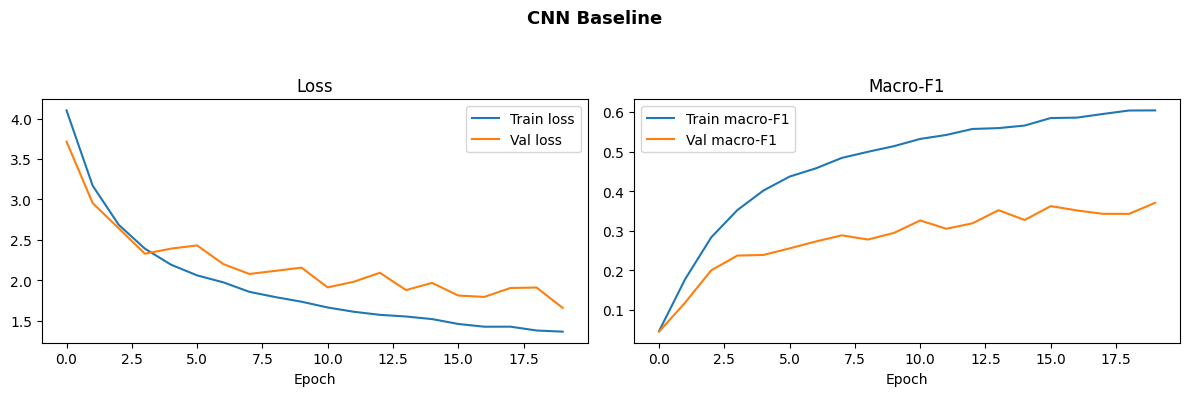

>>> Best checkpoint for CNN Baseline: epoch 20 (val_loss=1.6563, val_f1=0.3707)


In [93]:
class BasicCNN(nn.Module):
    """Three plain conv+ReLU+pool layers (16->32->64 filters). No block
    structure, no regularization at all -- the simplest possible baseline."""

    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding='same'), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding='same'), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding='same'), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.out_dim = out_dim
        self.proj = nn.Linear(64, out_dim)

    def forward(self, x):
        return self.proj(self.pool(self.features(x)).flatten(1))


class Classifier(nn.Module):
    """Thin classification head on top of any encoder -- turns its embedding
    into class logits. Shared by every image-only model in Steps 9-11."""

    def __init__(self, encoder, n_classes):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Linear(encoder.out_dim, n_classes)

    def forward(self, x):
        return self.head(self.encoder(x))


torch.manual_seed(RANDOM_STATE)
model_baseline = Classifier(BasicCNN(), N_CLASSES_1).to(DEVICE)
model_baseline, f1_baseline, epoch_baseline = fit(
    model_baseline, train_loader1, val_loader1, model_name="CNN Baseline", epochs=EPOCHS_BASELINE)


**What we got:** macro-F1 = **0.368** (accuracy 53.9%).

**What it tells us:** a jump from 0.003 to 0.368 confirms the pipeline genuinely works
and that photos really do carry useful information about what the item is. We're not
expecting this simple model to be competitive — it's a sanity check, and it passed.

## 9. Image-Only Model — ResNet-Style CNN

**What we're doing:** trying a deeper, more capable architecture — ResNet18's design,
but trained completely from scratch (no pretrained weights borrowed from elsewhere).

**The one new idea here: skip connections.** In a very deep network, information can
get "diluted" the further it travels through layer after layer. A skip connection lets
information take a shortcut past a layer instead of always going the long way round,
which makes deep networks much easier to train well.

ResNet-style CNN 1/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

ResNet-style CNN 1/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/30 - train_loss: 1.5043 - val_loss: 1.2925 - train_f1: 0.5940 - val_f1: 0.5080 - lr: 3.00e-04


ResNet-style CNN 2/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

ResNet-style CNN 2/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

ResNet-style CNN 24/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 24/30 - train_loss: 0.0451 - val_loss: 0.6388 - train_f1: 0.9853 - val_f1: 0.6892 - lr: 3.75e-05


ResNet-style CNN 25/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

ResNet-style CNN 25/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 25/30 - train_loss: 0.0408 - val_loss: 0.6319 - train_f1: 0.9858 - val_f1: 0.6967 - lr: 3.75e-05
Early stopping triggered at epoch 25 (best epoch was 20)


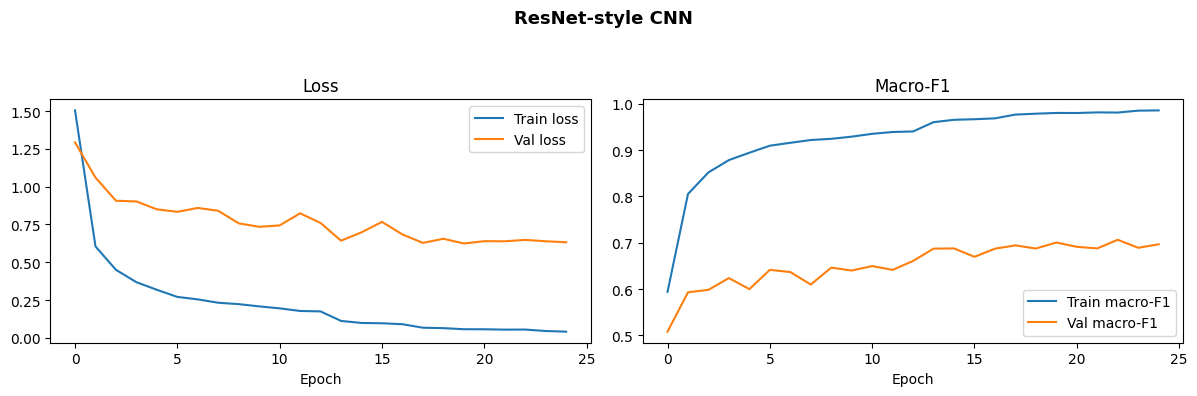

>>> Best checkpoint for ResNet-style CNN: epoch 20 (val_loss=0.6239, val_f1=0.7005)


In [94]:
from torchvision.models import resnet18


class ResNetStyleCNN(nn.Module):
    """ResNet18 architecture, randomly initialized -- trains entirely on
    this dataset, no pretrained weights."""

    def __init__(self, out_dim=128):
        super().__init__()
        backbone = resnet18(weights=None)
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.out_dim = out_dim
        self.proj = nn.Linear(512, out_dim)

    def forward(self, x):
        return self.proj(self.backbone(x))


torch.manual_seed(RANDOM_STATE)
model_resnet = Classifier(ResNetStyleCNN(), N_CLASSES_1).to(DEVICE)
model_resnet, f1_resnet, epoch_resnet = fit(
    model_resnet, train_loader1, val_loader1, model_name="ResNet-style CNN", epochs=EPOCHS_RESNET)


**What we got:** macro-F1 = **0.701** (accuracy 84.4%).

**What it tells us:** a huge jump over the Basic CNN's 0.368. Depth and skip connections
are clearly earning their keep here. This becomes our first genuinely serious,
deployable model.

## 10. Image-Only Model — SE-Residual CNN

**What we're doing:** trying a custom architecture, built specifically for these small
(80×60) photos rather than assuming large 224×224 images the way standard ResNet18
does. It combines two ideas:

- **Skip connections** (same idea as Section 9).
- **Squeeze-and-Excitation ("SE") attention** — after the model extracts a set of
  features from the image, this lets it learn to turn up the "volume" on whichever
  features actually matter for a given photo, and turn down the ones that don't. Think
  of it as the model learning to pay more attention to some clues than others.

**A couple of building blocks used throughout this model, in plain terms:**

- **BatchNorm** keeps the numbers flowing through the network in a stable, consistent
  range as training goes on, which usually makes training faster and more reliable.
- **Dropout** randomly switches off a fraction of the model's internal connections
  during training only. This stops the model from leaning too hard on any one specific
  connection, which helps it generalise to new photos instead of memorising the
  training ones.

SE-Residual CNN (from scratch) 1/35 train:   0%|          | 0/444 [00:00<?, ?it/s]

SE-Residual CNN (from scratch) 1/35 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/35 - train_loss: 3.1650 - val_loss: 2.4324 - train_f1: 0.1805 - val_f1: 0.2009 - lr: 3.00e-04


SE-Residual CNN (from scratch) 2/35 train:   0%|          | 0/444 [00:00<?, ?it/s]

SE-Residual CNN (from scratch) 2/35 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

SE-Residual CNN (from scratch) 29/35 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 29/35 - train_loss: 0.1153 - val_loss: 0.6101 - train_f1: 0.9597 - val_f1: 0.6837 - lr: 7.50e-05


SE-Residual CNN (from scratch) 30/35 train:   0%|          | 0/444 [00:00<?, ?it/s]

SE-Residual CNN (from scratch) 30/35 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 30/35 - train_loss: 0.1022 - val_loss: 0.6112 - train_f1: 0.9649 - val_f1: 0.7086 - lr: 7.50e-05
Early stopping triggered at epoch 30 (best epoch was 25)


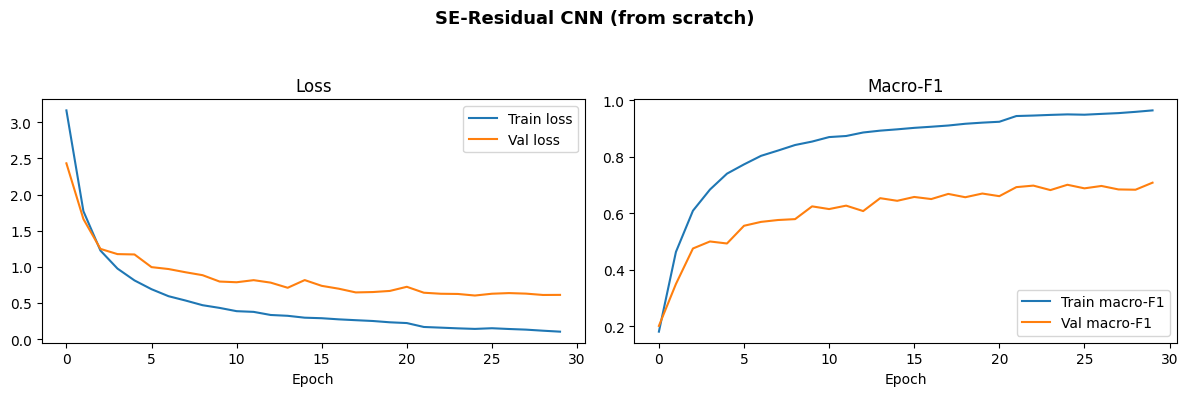

>>> Best checkpoint for SE-Residual CNN (from scratch): epoch 25 (val_loss=0.6023, val_f1=0.7012)
>>> SE-Residual CNN: val macro-F1 = 0.701, 2.88M parameters
>>> ResNet-style CNN for comparison: 0.701


In [95]:
# Randomly initialised throughout -- no torchvision backbone, no `weights=`
# argument -- so this stays a fully self-trained model.
import torch.nn.functional as F


class SqueezeExcite(nn.Module):
    """Channel attention: pool each feature map to one number, learn a per-channel
    gate from those numbers, then rescale. Lets the network decide which feature
    maps matter for a given image rather than weighting all of them equally."""

    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.fc1 = nn.Linear(channels, hidden)
        self.fc2 = nn.Linear(hidden, channels)

    def forward(self, x):
        s = x.mean(dim=(2, 3))                       # global average pool -> (B, C)
        s = torch.sigmoid(self.fc2(F.silu(self.fc1(s))))
        return x * s[:, :, None, None]


class SEResidualBlock(nn.Module):
    """Pre-activation residual block: BN -> SiLU -> conv, twice, plus a
    squeeze-excite gate and a skip connection. Pre-activation keeps the skip path
    a clean identity, which trains more stably at depth than the post-activation
    ordering used by the earlier blocks in this notebook."""

    def __init__(self, in_ch, out_ch, stride=1, drop=0.0):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.se = SqueezeExcite(out_ch)
        self.drop = nn.Dropout2d(drop) if drop > 0 else nn.Identity()
        self.shortcut = (nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False)
                         if (stride != 1 or in_ch != out_ch) else nn.Identity())

    def forward(self, x):
        out = F.silu(self.bn1(x))
        shortcut = self.shortcut(out if not isinstance(self.shortcut, nn.Identity) else x)
        out = self.conv1(out)
        out = self.conv2(F.silu(self.bn2(out)))
        out = self.se(self.drop(out))
        return out + shortcut


class SEResidualCNN(nn.Module):
    """From-scratch SE-residual encoder sized for 80x60 inputs.
    Stages 32 -> 64 -> 128 -> 256, two blocks each, downsampling only between
    stages: 80x60 -> 40x30 -> 20x15 -> 10x8."""

    def __init__(self, out_dim=128, widths=(32, 64, 128, 256), drop=0.1):
        super().__init__()
        self.stem = nn.Conv2d(3, widths[0], 3, padding=1, bias=False)   # stride 1: no early loss
        stages = []
        in_ch = widths[0]
        for stage_idx, width in enumerate(widths):
            stride = 1 if stage_idx == 0 else 2
            stages.append(SEResidualBlock(in_ch, width, stride=stride, drop=drop))
            stages.append(SEResidualBlock(width, width, stride=1, drop=drop))
            in_ch = width
        self.stages = nn.Sequential(*stages)
        self.norm = nn.BatchNorm2d(in_ch)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.out_dim = out_dim
        self.proj = nn.Sequential(nn.Dropout(0.2), nn.Linear(in_ch, out_dim))

    def forward(self, x):
        x = self.stages(self.stem(x))
        x = self.pool(F.silu(self.norm(x))).flatten(1)
        return self.proj(x)


torch.manual_seed(RANDOM_STATE)
model_seres = Classifier(SEResidualCNN(), N_CLASSES_1).to(DEVICE)
seres_param_groups = get_param_groups(model_seres, weight_decay=5e-4)
model_seres, f1_seres, epoch_seres = fit(
    model_seres, train_loader1, val_loader1, model_name="SE-Residual CNN (from scratch)",
    param_groups=seres_param_groups, epochs=EPOCHS_SERES)

n_params = sum(p.numel() for p in model_seres.parameters())
print(f">>> SE-Residual CNN: val macro-F1 = {f1_seres:.3f}, {n_params/1e6:.2f}M parameters")
print(f">>> ResNet-style CNN for comparison: {f1_resnet:.3f}")


**What we got:** macro-F1 = **0.701** — essentially identical to the ResNet-style CNN's
0.701 from Section 9 (0.7012 vs 0.7005 to be precise — a hair's difference, not a real
one).

**What it tells us:** as plain image-only models, these two are a genuine tie. Neither
is clearly "the" better architecture on its own — Section 17's statistics confirm this
formally. The more interesting question becomes which one pairs better with the extra
metadata later on.

## 11. Image-Only Model Comparison

| Model | Macro-F1 |
|---|---:|
| Majority baseline | 0.003 |
| Basic CNN | 0.368 |
| ResNet-style CNN | 0.701 |
| SE-Residual CNN | 0.701 |

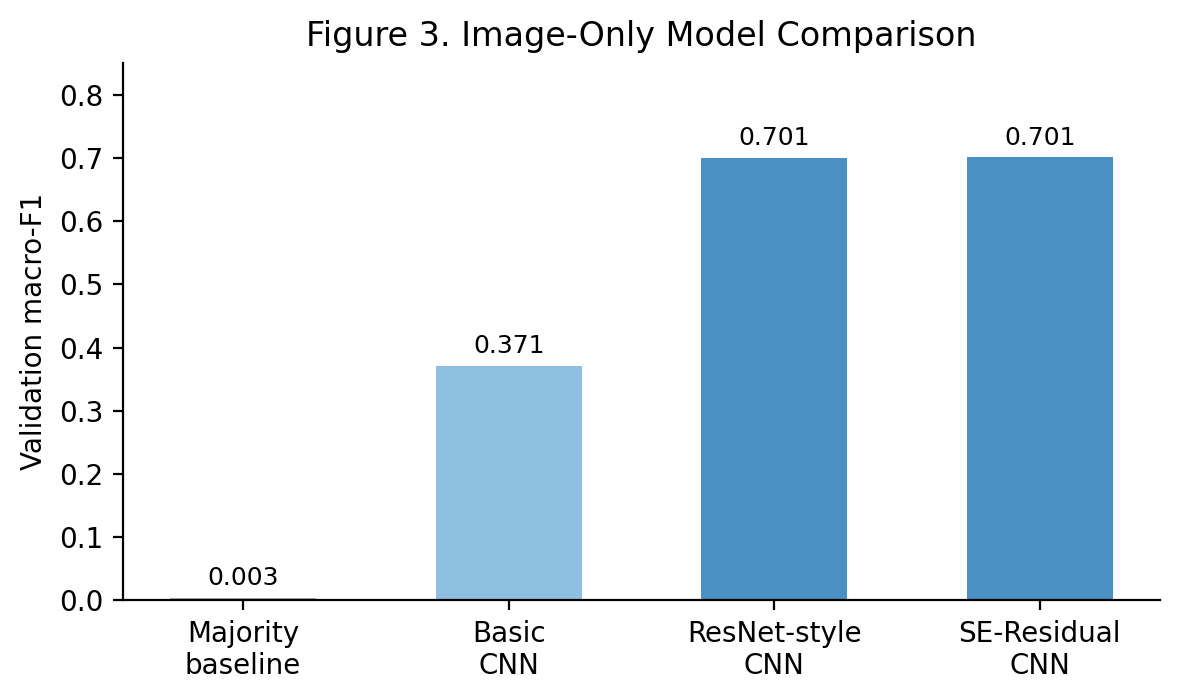

In [143]:
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 10, "font.family": "sans-serif"})

models = ["Majority\nbaseline", "Basic\nCNN", "ResNet-style\nCNN", "SE-Residual\nCNN"]
scores = [baseline_f1, f1_baseline, f1_resnet, f1_seres]
colors = ["#b0b0b0", "#8fbfe0", "#4a90c4", "#4a90c4"]

fig, ax = plt.subplots(figsize=(6, 3.6), dpi=200)
bars = ax.bar(models, scores, color=colors, width=0.55)

for b, s in zip(bars, scores):
    ax.text(b.get_x() + b.get_width()/2, s + 0.02, f"{s:.3f}", ha="center", fontsize=9)

ax.set_ylabel("Validation macro-F1")
ax.set_ylim(0, max(scores) + 0.15)
ax.set_title("Figure 3. Image-Only Model Comparison")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

**What it tells us:** both real architectures land far ahead of the Basic CNN and are
statistically tied with each other. Either is a solid deployment candidate on its own,
since both only need a photo — no other information. The next question: can we do even
better by also using the extra spreadsheet data (colour, gender, season, usage) that
comes with each item?

## 12. Metadata-Only Baseline

**What we're doing:** the opposite experiment — throw away the photo entirely, and try
to guess the category using *only* the spreadsheet columns (gender, colour, season,
usage, year), with a simple, well-understood model called Logistic Regression.

**Why:** if this alone does well, that would be a red flag — it would suggest the label
is somehow "leaking" through the spreadsheet in an unfair way. If it does badly, that
confirms the photo really is doing the heavy lifting, which is what we'd expect.

In [96]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

ORACLE_CATEGORICAL = ['gender', 'baseColour', 'season', 'usage']
ORACLE_NUMERIC = ['year']


def sanitize_metadata(df, categorical_cols, numeric_cols):
    """Converts pandas nullable dtypes (pd.NA) to plain numpy NaN --
    sklearn's SimpleImputer/OneHotEncoder don't handle pd.NA correctly."""
    out = df[categorical_cols + numeric_cols].copy()
    for col in categorical_cols:
        out[col] = out[col].astype(object).where(out[col].notna(), np.nan)
    for col in numeric_cols:
        out[col] = pd.to_numeric(out[col], errors='coerce').astype(float)
    return out


meta_frame_train = sanitize_metadata(task1_train, ORACLE_CATEGORICAL, ORACLE_NUMERIC)
meta_frame_val = sanitize_metadata(task1_val, ORACLE_CATEGORICAL, ORACLE_NUMERIC)

metadata_preprocessor = ColumnTransformer([
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), ORACLE_CATEGORICAL),
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), ORACLE_NUMERIC),
])

# Fit on train only -- same rule as every encoder/scaler elsewhere in this notebook.
X_meta_train = metadata_preprocessor.fit_transform(meta_frame_train)
X_meta_val = metadata_preprocessor.transform(meta_frame_val)
if hasattr(X_meta_train, "toarray"):
    X_meta_train, X_meta_val = X_meta_train.toarray(), X_meta_val.toarray()

y_meta_train = task1_train[TASK1_TARGET_ENC].values
y_meta_val = task1_val[TASK1_TARGET_ENC].values

print(f"Metadata feature shape: train={X_meta_train.shape}, val={X_meta_val.shape}")


Metadata feature shape: train=(28371, 64), val=(9455, 64)


In [97]:
logreg = LogisticRegression(
    solver='lbfgs', max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE,
)
logreg.fit(X_meta_train, y_meta_train)

pred_logreg = logreg.predict(X_meta_val)
acc_logreg = accuracy_score(y_meta_val, pred_logreg)
f1_logreg = f1_score(y_meta_val, pred_logreg, average='macro', zero_division=0)

print(f"Metadata-only Logistic Regression: accuracy={acc_logreg:.3f}, macro-F1={f1_logreg:.3f}")


Metadata-only Logistic Regression: accuracy=0.203, macro-F1=0.133


**What we got:** accuracy 20.3%, macro-F1 = **0.133**.

**What it tells us:** far below any of the image models (0.701), only a little above
the 0.003 do-nothing baseline. That makes sense — knowing an item is "blue, Casual,
Men's" doesn't tell you if it's a T-shirt, shorts, or a dozen other things. This
confirms the photo is essential, not optional, and rules out any worry that the
spreadsheet data alone could solve this.

## 13. Check Metadata Availability at Test Time

**What we're doing:** before getting excited about combining the photo *and* the
spreadsheet data, we check something easy to overlook — is that spreadsheet data
actually available for the real, unseen test photos we'll eventually need to predict?

In [98]:
test_check_df = pd.read_csv(TEST_PRED_CSV)
print("Test prediction file columns:", test_check_df.columns.tolist())
print(test_check_df.head())

required_cols = ORACLE_CATEGORICAL + ORACLE_NUMERIC
missing_entirely = [c for c in required_cols if c not in test_check_df.columns]
present_but_empty = [c for c in required_cols
                      if c in test_check_df.columns and test_check_df[c].isna().all()]

print(f"\nRequired Multi-Input metadata columns: {required_cols}")
print(f"Missing from the test file entirely: {missing_entirely}")
print(f"Present as a column name but entirely empty "
      f"(these are targets to PREDICT across the assignment's tasks, not given inputs): {present_but_empty}")

MULTIINPUT_TEST_ELIGIBLE = (len(missing_entirely) == 0) and (len(present_but_empty) == 0)
print(f"\n>>> Multi-Input CNN (and the metadata-only LR/RF models above, which use the "
      f"same features) Final-Test Eligible: {MULTIINPUT_TEST_ELIGIBLE}")
if not MULTIINPUT_TEST_ELIGIBLE:
    print(">>> Reason: baseColour/year are absent from the test file entirely, and "
          "gender/season/usage are present only as empty columns to be predicted -- "
          "none of these can be supplied as real inputs at test time.")


Test prediction file columns: ['id', 'gender', 'articleType', 'season', 'usage']
      id  gender  articleType  season  usage
0  52003     NaN          NaN     NaN    NaN
1  52007     NaN          NaN     NaN    NaN
2  52017     NaN          NaN     NaN    NaN
3  52021     NaN          NaN     NaN    NaN
4  52023     NaN          NaN     NaN    NaN

Required Multi-Input metadata columns: ['gender', 'baseColour', 'season', 'usage', 'year']
Missing from the test file entirely: ['baseColour', 'year']
Present as a column name but entirely empty (these are targets to PREDICT across the assignment's tasks, not given inputs): ['gender', 'season', 'usage']

>>> Multi-Input CNN (and the metadata-only LR/RF models above, which use the same features) Final-Test Eligible: False
>>> Reason: baseColour/year are absent from the test file entirely, and gender/season/usage are present only as empty columns to be predicted -- none of these can be supplied as real inputs at test time.


**What we got:** the real test file only has 5 columns: `id`, `gender`,
`articleType`, `season`, `usage`. `baseColour` and `year` aren't in it at all. And
`gender`, `season`, and `usage` exist as column names, but every single value is
**empty** — because predicting those is literally the job of Task 2 and Task 3, not
information handed to us.

**What it tells us — and why this is the most important finding in the whole
notebook:** any model that *needs* this metadata to make a prediction can't actually be
used on the real test photos, no matter how good it looks in our experiments. So from
here on we track two very different kinds of result:

- **Oracle experiments** — we hand the model the *true* metadata, just to find out
  whether that information is useful *in principle*.
- **Deployment reality** — on a real test photo, that metadata doesn't exist yet; it
  would have to be *predicted* first (by Task 2 and 3's own models), and predictions
  are never perfect.

A model can look great under oracle conditions and still be the wrong choice once
reality gets involved. Section 20 tests that directly.

## 14. Multi-Input CNN — Oracle Experiment

**What we're doing:** building a model that looks at *both* the photo and the true
metadata at the same time, to answer: does the metadata add anything the photo alone
doesn't already tell us?

**How it works:** the image goes through a CNN (like Sections 9–10) and gets turned
into a list of numbers summarising what's in the photo. The metadata (gender, colour,
season, usage, year) goes through a small separate network of its own. Those two lists
of numbers are then joined together (**concatenated**) and fed into one final layer
that makes the actual prediction. Both halves get to contribute.

This is deliberately an **oracle** experiment (see Section 13) — we're testing whether
metadata is useful at all, not claiming this score is something we'll actually get on
the real test set.

Pre-loading 28371 images into memory...
Done.
Pre-loading 9455 images into memory...
Done.


Multi-Input CNN (Image + Metadata) 1/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN (Image + Metadata) 1/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/30 - train_loss: 2.3764 - val_loss: 1.4792 - train_f1: 0.3875 - val_f1: 0.4449 - lr: 3.00e-04


Multi-Input CNN (Image + Metadata) 2/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

...

Multi-Input CNN (Image + Metadata) 23/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 23/30 - train_loss: 0.0715 - val_loss: 0.5336 - train_f1: 0.9771 - val_f1: 0.7415 - lr: 7.50e-05


Multi-Input CNN (Image + Metadata) 24/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN (Image + Metadata) 24/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 24/30 - train_loss: 0.0623 - val_loss: 0.5306 - train_f1: 0.9808 - val_f1: 0.7380 - lr: 7.50e-05
Early stopping triggered at epoch 24 (best epoch was 19)


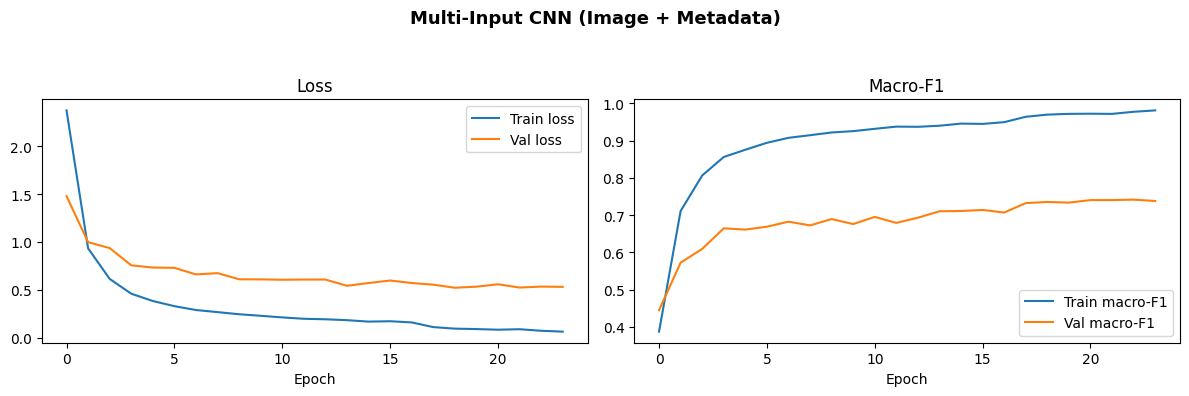

>>> Best checkpoint for Multi-Input CNN (Image + Metadata): epoch 19 (val_loss=0.5215, val_f1=0.7353)


In [99]:
class MultiInputDataset(Dataset):
    """Returns (image, metadata, label) triplets. `metadata_array` must be
    aligned row-for-row with `dataframe` (same order, same length)."""

    def __init__(self, dataframe, metadata_array, images_dir, target_col_enc, transform):
        self.df = dataframe.reset_index(drop=True)
        self.metadata = np.asarray(metadata_array, dtype=np.float32)
        assert len(self.metadata) == len(self.df), "metadata_array must align with dataframe rows"
        self.images_dir = images_dir
        self.target_col_enc = target_col_enc
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(self.images_dir / f"{row['id']}.jpg") as im:
            img = self.transform(im)
        meta = torch.tensor(self.metadata[idx], dtype=torch.float32)
        label = int(row[self.target_col_enc])
        return img, meta, torch.tensor(label, dtype=torch.long)


class MetadataEncoder(nn.Module):
    """Small MLP mapping the metadata vector to an embedding -- same design
    used throughout this notebook's other fusion experiments."""

    def __init__(self, in_dim, out_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, out_dim), nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class MultiInputNet(nn.Module):
    """Fuses an image embedding (from any encoder with an .out_dim attribute
    -- BasicCNN/ResNetStyleCNN/SEResidualCNN all already expose this) and a
    metadata embedding by concatenation, then classifies from the combined
    vector."""

    def __init__(self, image_encoder, meta_dim, n_classes, meta_embedding_dim=64):
        super().__init__()
        self.image_encoder = image_encoder
        self.meta_encoder = MetadataEncoder(meta_dim, out_dim=meta_embedding_dim)
        self.classifier = nn.Sequential(
            nn.Linear(image_encoder.out_dim + meta_embedding_dim, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, n_classes),
        )

    def forward(self, img, meta):
        img_emb = self.image_encoder(img)
        meta_emb = self.meta_encoder(meta)
        return self.classifier(torch.cat([img_emb, meta_emb], dim=1))


multi_train_ds = CachedMultiInputDataset(task1_train, X_meta_train, IMAGES_TRAIN_DIR, TASK1_TARGET_ENC, train_transform)
multi_val_ds = CachedMultiInputDataset(task1_val, X_meta_val, IMAGES_TRAIN_DIR, TASK1_TARGET_ENC, eval_transform)

multi_sampler = get_weighted_sampler(task1_train, TASK1_TARGET_ENC)
multi_train_loader = DataLoader(multi_train_ds, batch_size=BATCH_SIZE, sampler=multi_sampler,
                                 num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
multi_val_loader = DataLoader(multi_val_ds, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

torch.manual_seed(RANDOM_STATE)
model_multi = MultiInputNet(ResNetStyleCNN(), meta_dim=X_meta_train.shape[1], n_classes=N_CLASSES_1).to(DEVICE)
multi_param_groups = get_param_groups(model_multi, weight_decay=1e-4)
model_multi, f1_multi, epoch_multi = fit(
    model_multi, multi_train_loader, multi_val_loader, model_name="Multi-Input CNN (Image + Metadata)",
    param_groups=multi_param_groups, epochs=EPOCHS_RESNET, patience=5)


## Multi-Input CNN on the SE-Residual encoder

We try this fusion idea with *both* image encoders from Sections 9–10, not just one —
same metadata, same setup, only the image half changes. That way we're not stuck
guessing which encoder pairs better with metadata; we can just check both.

Multi-Input CNN (SE-Residual encoder) 1/35 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN (SE-Residual encoder) 1/35 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/35 - train_loss: 3.4966 - val_loss: 2.4647 - train_f1: 0.1181 - val_f1: 0.1986 - lr: 3.00e-04


Multi-Input CNN (SE-Residual encoder) 2/35 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN (SE-Residual encoder) 2/35 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

Multi-Input CNN (SE-Residual encoder) 34/35 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 34/35 - train_loss: 0.1654 - val_loss: 0.5046 - train_f1: 0.9460 - val_f1: 0.7488 - lr: 7.50e-05


Multi-Input CNN (SE-Residual encoder) 35/35 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN (SE-Residual encoder) 35/35 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 35/35 - train_loss: 0.1604 - val_loss: 0.4856 - train_f1: 0.9448 - val_f1: 0.7424 - lr: 7.50e-05


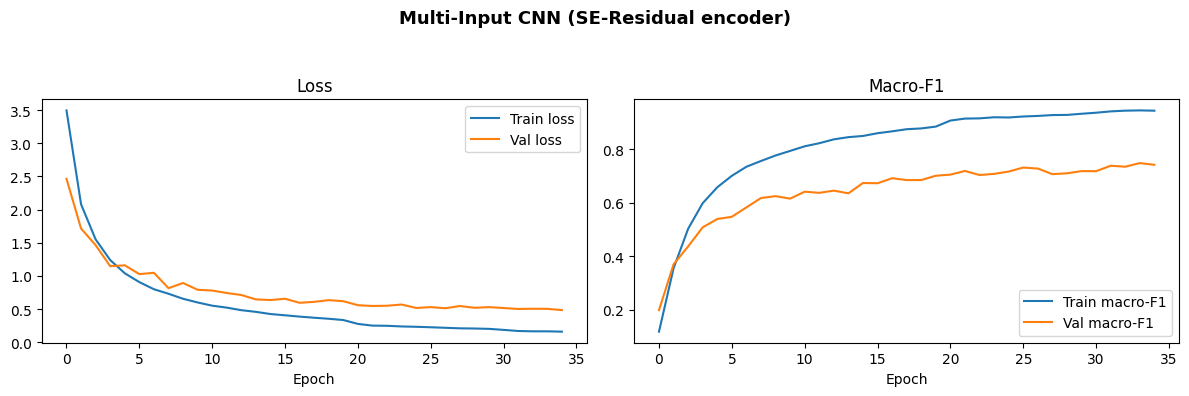

>>> Best checkpoint for Multi-Input CNN (SE-Residual encoder): epoch 35 (val_loss=0.4856, val_f1=0.7424)
Multi-Input (SE-Residual): 0.742  vs  Multi-Input (ResNet-style): 0.735


In [100]:
# Second multi-input candidate, using the from-scratch SE-Residual encoder instead
# of the ResNet-style one, so "best multi-input model" (Section 23) is a genuine
# choice rather than the only candidate trained.
torch.manual_seed(RANDOM_STATE)
model_multi_seres = MultiInputNet(SEResidualCNN(), meta_dim=X_meta_train.shape[1],
                                  n_classes=N_CLASSES_1).to(DEVICE)
multi_seres_param_groups = get_param_groups(model_multi_seres, weight_decay=1e-4)
model_multi_seres, f1_multi_seres, epoch_multi_seres = fit(
    model_multi_seres, multi_train_loader, multi_val_loader,
    model_name="Multi-Input CNN (SE-Residual encoder)",
    param_groups=multi_seres_param_groups, epochs=EPOCHS_SERES, patience=5)

y_true_multi_seres, pred_multi_seres = get_predictions(model_multi_seres, multi_val_loader)
print(f"Multi-Input (SE-Residual): {f1_multi_seres:.3f}  vs  "
      f"Multi-Input (ResNet-style): {f1_multi:.3f}")


**What we got:**

| Image encoder + metadata | Macro-F1 |
|---|---:|
| ResNet-style + oracle metadata | 0.735 |
| SE-Residual + oracle metadata | **0.742** |

**What it tells us:** both are clearly better than either image-only model on its own
(0.701). Adding true metadata genuinely helps — roughly +0.03 to +0.04 macro-F1 — when
we're allowed to cheat and hand the model the correct answers for gender/colour/season/
usage. The SE-Residual pairing comes out slightly ahead and turns out to be the best
single score of anything trained in this entire notebook.

But — and this is the whole point of Section 13 — "best score" isn't the same as "best
choice." This is still an oracle result. Whether it survives contact with a real test
photo (where that metadata has to be predicted, not given) is exactly what Section 20
checks.

## 15. Metadata Ablation Study

**What we're doing:** the Multi-Input model improved once we added metadata — but
*which* piece of metadata is actually responsible? We find out by removing one feature
at a time and retraining, comparing each result back to the full oracle bundle
(0.735, from the ResNet-based Multi-Input CNN in Section 14).

### **15.1 — Does `year` matter?**

In [101]:
# Metadata WITHOUT year -- everything else about the preprocessing pipeline
# stays identical to the oracle version above (same fit-on-train-only rule,
# same categorical encoding).
ORACLE_CATEGORICAL_NO_YEAR = ['gender', 'baseColour', 'season', 'usage']

metadata_preprocessor_no_year = ColumnTransformer([
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), ORACLE_CATEGORICAL_NO_YEAR),
])

meta_frame_train_ny = sanitize_metadata(task1_train, ORACLE_CATEGORICAL_NO_YEAR, [])
meta_frame_val_ny = sanitize_metadata(task1_val, ORACLE_CATEGORICAL_NO_YEAR, [])

X_meta_train_no_year = metadata_preprocessor_no_year.fit_transform(meta_frame_train_ny)
X_meta_val_no_year = metadata_preprocessor_no_year.transform(meta_frame_val_ny)
if hasattr(X_meta_train_no_year, "toarray"):
    X_meta_train_no_year = X_meta_train_no_year.toarray()
    X_meta_val_no_year = X_meta_val_no_year.toarray()

print(f"Metadata feature shape (no year): train={X_meta_train_no_year.shape}, "
      f"val={X_meta_val_no_year.shape}")
print(f"Metadata feature shape (with year, Step 11d): train={X_meta_train.shape}, "
      f"val={X_meta_val.shape}")


Metadata feature shape (no year): train=(28371, 63), val=(9455, 63)
Metadata feature shape (with year, Step 11d): train=(28371, 64), val=(9455, 64)


Pre-loading 28371 images into memory...
Done.
Pre-loading 9455 images into memory...
Done.


Multi-Input CNN, no year (ablation) 1/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN, no year (ablation) 1/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/30 - train_loss: 2.3766 - val_loss: 1.4935 - train_f1: 0.3751 - val_f1: 0.4377 - lr: 3.00e-04


Multi-Input CNN, no year (ablation) 2/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

...

Multi-Input CNN, no year (ablation) 26/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 26/30 - train_loss: 0.0640 - val_loss: 0.5464 - train_f1: 0.9787 - val_f1: 0.7416 - lr: 7.50e-05


Multi-Input CNN, no year (ablation) 27/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN, no year (ablation) 27/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 27/30 - train_loss: 0.0577 - val_loss: 0.5662 - train_f1: 0.9810 - val_f1: 0.7268 - lr: 7.50e-05
Early stopping triggered at epoch 27 (best epoch was 22)


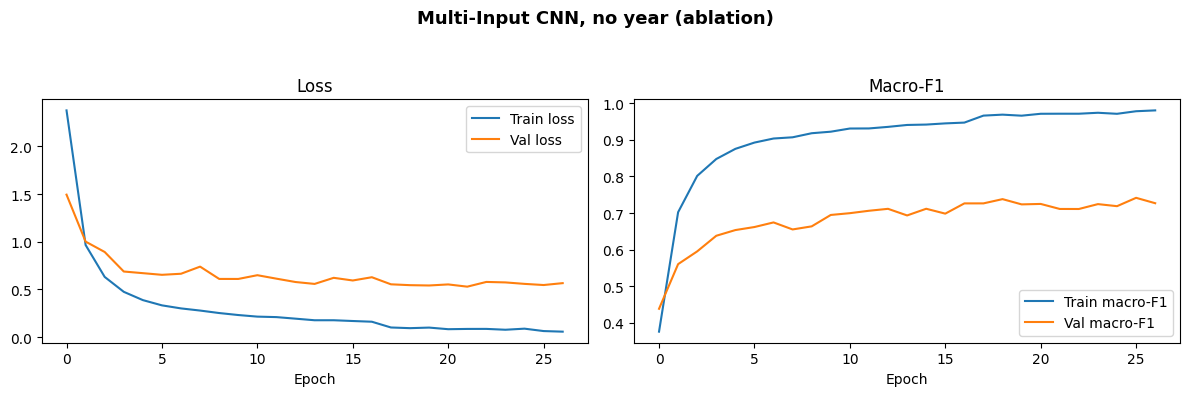

>>> Best checkpoint for Multi-Input CNN, no year (ablation): epoch 22 (val_loss=0.5293, val_f1=0.7111)


In [102]:
multi_train_ds_ny = CachedMultiInputDataset(task1_train, X_meta_train_no_year, IMAGES_TRAIN_DIR,
                                       TASK1_TARGET_ENC, train_transform)
multi_val_ds_ny = CachedMultiInputDataset(task1_val, X_meta_val_no_year, IMAGES_TRAIN_DIR,
                                     TASK1_TARGET_ENC, eval_transform)

multi_train_loader_ny = DataLoader(multi_train_ds_ny, batch_size=BATCH_SIZE, sampler=multi_sampler,
                                    num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
multi_val_loader_ny = DataLoader(multi_val_ds_ny, batch_size=BATCH_SIZE, shuffle=False,
                                  num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

torch.manual_seed(RANDOM_STATE)
model_multi_no_year = MultiInputNet(ResNetStyleCNN(), meta_dim=X_meta_train_no_year.shape[1],
                                     n_classes=N_CLASSES_1).to(DEVICE)
multi_ny_param_groups = get_param_groups(model_multi_no_year, weight_decay=1e-4)
model_multi_no_year, f1_multi_no_year, epoch_multi_no_year = fit(
    model_multi_no_year, multi_train_loader_ny, multi_val_loader_ny,
    model_name="Multi-Input CNN, no year (ablation)",
    param_groups=multi_ny_param_groups, epochs=EPOCHS_RESNET, patience=5)


**What we got (dropping `year`):** macro-F1 drops from 0.735 to **0.711** — a real
drop of about 0.024.

**What it tells us:** `year` is genuinely contributing something, not just that much so we are droping it

### **15.2 — Which single feature matters most?** 

The same one-feature-at-a-time test,
applied to `gender`, `baseColour`, `season`, and `usage`.

### What we want
A ranking of which single metadata feature the Multi-Input CNN leans on hardest — whichever
feature's removal causes the biggest drop is the one doing the most work. 

Multi-Input CNN, no gender (ablation) 1/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN, no gender (ablation) 1/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/30 - train_loss: 2.3615 - val_loss: 1.5768 - train_f1: 0.3846 - val_f1: 0.4443 - lr: 3.00e-04


Multi-Input CNN, no gender (ablation) 2/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN, no gender (ablation) 2/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

Multi-Input CNN, no gender (ablation) 21/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 21/30 - train_loss: 0.0808 - val_loss: 0.5541 - train_f1: 0.9744 - val_f1: 0.7221 - lr: 7.50e-05


Multi-Input CNN, no gender (ablation) 22/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN, no gender (ablation) 22/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 22/30 - train_loss: 0.0687 - val_loss: 0.5591 - train_f1: 0.9778 - val_f1: 0.7195 - lr: 7.50e-05
Early stopping triggered at epoch 22 (best epoch was 17)


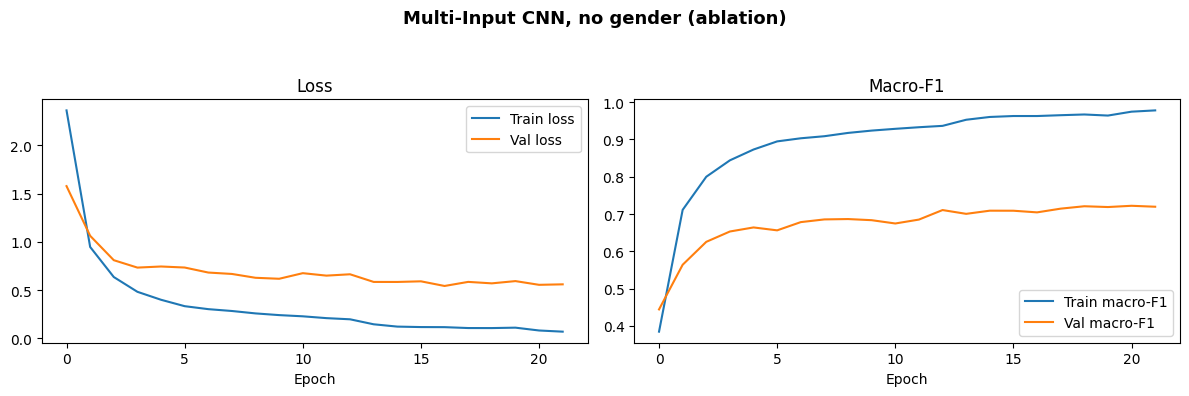

>>> Best checkpoint for Multi-Input CNN, no gender (ablation): epoch 17 (val_loss=0.5422, val_f1=0.7044)


Multi-Input CNN, no baseColour (ablation) 1/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN, no baseColour (ablation) 1/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/30 - train_loss: 2.4117 - val_loss: 1.4743 - train_f1: 0.3791 - val_f1: 0.4539 - lr: 3.00e-04


Multi-Input CNN, no baseColour (ablation) 2/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

...

Multi-Input CNN, no baseColour (ablation) 23/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 23/30 - train_loss: 0.0700 - val_loss: 0.5382 - train_f1: 0.9781 - val_f1: 0.7678 - lr: 7.50e-05


Multi-Input CNN, no baseColour (ablation) 24/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN, no baseColour (ablation) 24/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 24/30 - train_loss: 0.0586 - val_loss: 0.5656 - train_f1: 0.9815 - val_f1: 0.7640 - lr: 7.50e-05
Early stopping triggered at epoch 24 (best epoch was 19)


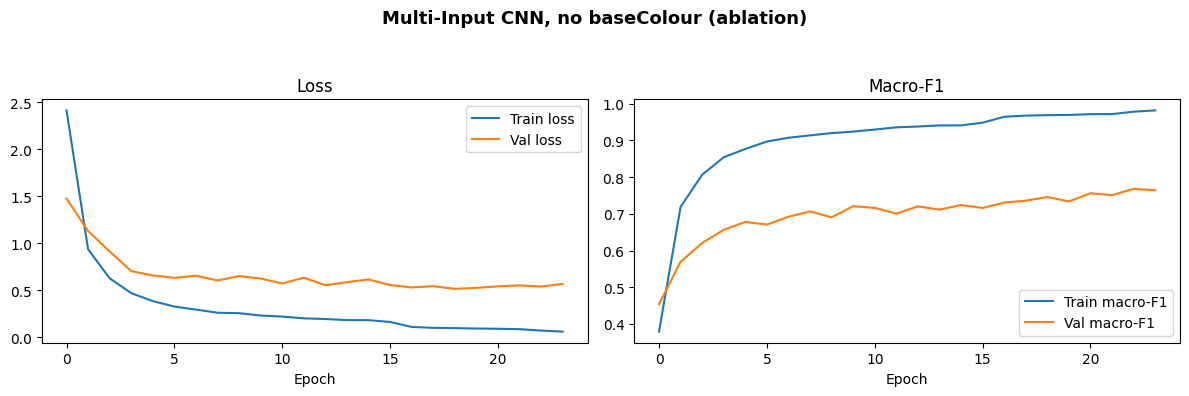

>>> Best checkpoint for Multi-Input CNN, no baseColour (ablation): epoch 19 (val_loss=0.5143, val_f1=0.7459)


Multi-Input CNN, no season (ablation) 1/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN, no season (ablation) 1/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/30 - train_loss: 2.3369 - val_loss: 1.5600 - train_f1: 0.3884 - val_f1: 0.4464 - lr: 3.00e-04


Multi-Input CNN, no season (ablation) 2/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

...

Multi-Input CNN, no season (ablation) 23/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 23/30 - train_loss: 0.0612 - val_loss: 0.5162 - train_f1: 0.9808 - val_f1: 0.7388 - lr: 3.75e-05


Multi-Input CNN, no season (ablation) 24/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN, no season (ablation) 24/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 24/30 - train_loss: 0.0543 - val_loss: 0.5264 - train_f1: 0.9827 - val_f1: 0.7449 - lr: 3.75e-05
Early stopping triggered at epoch 24 (best epoch was 19)


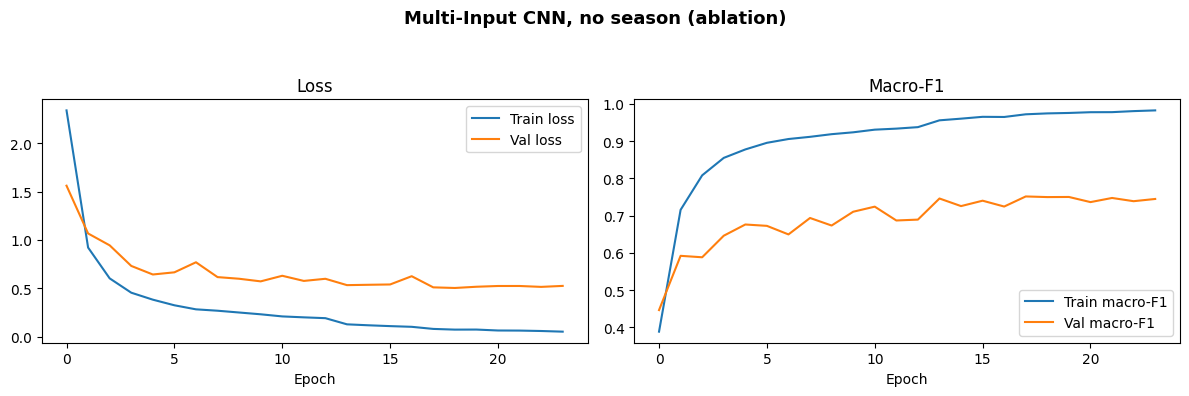

>>> Best checkpoint for Multi-Input CNN, no season (ablation): epoch 19 (val_loss=0.5050, val_f1=0.7499)


Multi-Input CNN, no usage (ablation) 1/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN, no usage (ablation) 1/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/30 - train_loss: 2.3720 - val_loss: 1.6056 - train_f1: 0.3756 - val_f1: 0.4528 - lr: 3.00e-04


Multi-Input CNN, no usage (ablation) 2/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

...

Multi-Input CNN, no usage (ablation) 23/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 23/30 - train_loss: 0.0859 - val_loss: 0.5948 - train_f1: 0.9720 - val_f1: 0.7354 - lr: 7.50e-05


Multi-Input CNN, no usage (ablation) 24/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN, no usage (ablation) 24/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 24/30 - train_loss: 0.0672 - val_loss: 0.6079 - train_f1: 0.9776 - val_f1: 0.7447 - lr: 7.50e-05
Early stopping triggered at epoch 24 (best epoch was 19)


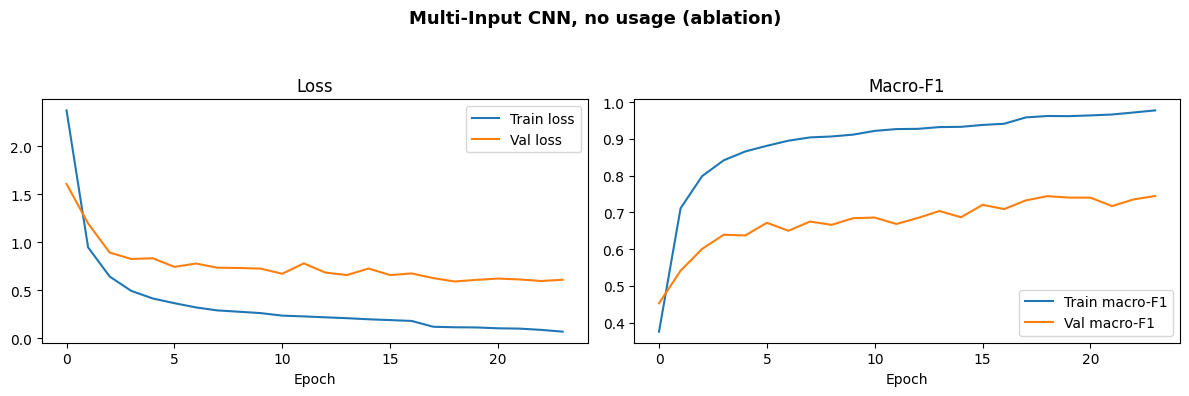

>>> Best checkpoint for Multi-Input CNN, no usage (ablation): epoch 19 (val_loss=0.5898, val_f1=0.7443)


In [103]:
def build_ablation_metadata(drop_feature):
    """Builds the metadata feature matrix with exactly one column removed
    from the full oracle set -- same preprocessing rule (fit on train only)
    as everywhere else in this notebook."""
    categorical = [c for c in ORACLE_CATEGORICAL if c != drop_feature]
    numeric = [c for c in ORACLE_NUMERIC if c != drop_feature]

    preprocessor = ColumnTransformer([
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), numeric),
    ]) if numeric else ColumnTransformer([
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical),
    ])

    meta_train_df = sanitize_metadata(task1_train, categorical, numeric)
    meta_val_df = sanitize_metadata(task1_val, categorical, numeric)

    X_train = preprocessor.fit_transform(meta_train_df)
    X_val = preprocessor.transform(meta_val_df)
    if hasattr(X_train, "toarray"):
        X_train, X_val = X_train.toarray(), X_val.toarray()
    return X_train, X_val


def train_ablation_model(drop_feature):
    """Trains one Multi-Input CNN with `drop_feature` removed from the
    metadata branch, using the exact same architecture/training setup as
    Step 11d's full-oracle model."""
    X_train, X_val = build_ablation_metadata(drop_feature)

    train_ds = MultiInputDataset(task1_train, X_train, IMAGES_TRAIN_DIR, TASK1_TARGET_ENC, train_transform)
    val_ds = MultiInputDataset(task1_val, X_val, IMAGES_TRAIN_DIR, TASK1_TARGET_ENC, eval_transform)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=multi_sampler,
                               num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

    torch.manual_seed(RANDOM_STATE)
    model = MultiInputNet(ResNetStyleCNN(), meta_dim=X_train.shape[1], n_classes=N_CLASSES_1).to(DEVICE)
    param_groups = get_param_groups(model, weight_decay=1e-4)
    model, f1_val, epoch = fit(
        model, train_loader, val_loader, model_name=f"Multi-Input CNN, no {drop_feature} (ablation)",
        param_groups=param_groups, epochs=EPOCHS_RESNET, patience=5)

    y_true, pred = get_predictions(model, val_loader)
    return model, y_true, pred


# Run all four single-feature-drop ablations
ablation_features = ['gender', 'baseColour', 'season', 'usage']
ablation_models = {}
ablation_predictions = {}

for feature in ablation_features:
    model, y_true_ab, pred_ab = train_ablation_model(feature)
    ablation_models[feature] = model
    ablation_predictions[feature] = (y_true_ab, pred_ab)

**What we got, dropping one feature at a time from the full 0.735 bundle:**

| Feature removed | Macro-F1 | Change |
|---|---:|---:|
| *(none — full bundle)* | 0.735 | — |
| `gender` | 0.704 | **−0.031** (biggest drop) |
| `year` | 0.711 | −0.024 |
| `usage` | 0.744 | +0.009 |
| `baseColour` | 0.746 | +0.011 |
| `season` | 0.750 | **+0.015** (biggest gain) |

**What it tells us — and this was genuinely surprising:** removing `gender` or `year`
makes the model *worse*, as we'd expect. But removing `baseColour`, `season`, or
`usage` actually makes the model slightly *better*. In other words, three of the five
metadata features weren't helping — they were adding a small amount of noise the model
had to learn to ignore. `gender` is doing the real work here, with `year` a distant
second.

That matters beyond curiosity: `gender` isn't something Task 1 predicts — it comes from
Task 3's own model. So the one metadata feature that actually helps is exactly the one
whose *real-world* value depends on another task's model being accurate, not on
anything Task 1 controls.

### **15.3 — A different angle: Random Forest feature importance.** 

A Random Forest is a
model built from many small decision trees; it can report which input columns it leaned
on most when trained on the metadata alone (no photo involved at all).

In [104]:
from sklearn.ensemble import RandomForestClassifier

rf_ablation = RandomForestClassifier(
    n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1,
)
rf_ablation.fit(X_meta_train, y_meta_train)

importances = pd.Series(rf_ablation.feature_importances_, index=metadata_preprocessor.get_feature_names_out())
print("Random Forest feature importances (metadata bundle):")
print(importances.sort_values(ascending=False))


Random Forest feature importances (metadata bundle):
num__year                            0.233634
cat__season_Summer                   0.036353
cat__baseColour_Blue                 0.034077
cat__baseColour_Black                0.032586
cat__gender_Women                    0.032256
                                       ...   
cat__baseColour_Sea Green            0.000221
cat__baseColour_Rose                 0.000179
cat__baseColour_Mushroom Brown       0.000118
cat__baseColour_Lime Green           0.000057
cat__baseColour_Fluorescent Green    0.000036
Length: 64, dtype: float64


In [105]:
# Aggregate one-hot-column-level importances back up to the original metadata
# feature -- comparing whole features ("gender" vs "year") is the fair
# comparison; comparing "gender_Women" vs "year" is not, since a categorical
# feature's importance is split across all of its category columns.
def original_feature_of(col_name):
    for c in ORACLE_CATEGORICAL:
        if col_name.startswith(f"cat__{c}_"):
            return c
    for c in ORACLE_NUMERIC:
        if col_name == f"num__{c}":
            return c
    return col_name  # fallback, shouldn't normally hit this

aggregated_importances = importances.groupby(original_feature_of).sum()
print("Random Forest feature importances, aggregated by original feature:")
print(aggregated_importances.sort_values(ascending=False))


Random Forest feature importances, aggregated by original feature:
baseColour    0.447988
year          0.233634
season        0.112523
gender        0.107906
usage         0.097948
dtype: float64


**What we got:**

| Feature | Random Forest importance |
|---|---:|
| `baseColour` | 0.448 (highest) |
| `year` | 0.234 |
| `season` | 0.113 |
| `gender` | 0.108 |
| `usage` | 0.098 |

**What it tells us — and why it doesn't contradict the ablation above:** the Random
Forest says `baseColour` is the single most useful column for guessing the category
*from metadata alone*. But the ablation just showed that removing `baseColour` from the
*photo + metadata* model actually helped, not hurt. Both are true at once, because
they're answering different questions:

- Random Forest: "if all I have is the spreadsheet, which column tells me the most?"
- Ablation: "given the model already has the photo, does this extra column still add
  anything?"

`baseColour` is informative on its own, but the CNN was probably already picking up
colour information straight from the pixels — so handing it colour *again* as a
separate metadata column was redundant, and redundant information can act as noise
rather than help. `gender`, on the other hand, isn't something you can see directly in
a product photo the same way, which is likely why it's the one feature that genuinely
adds something the image alone doesn't already have.

##  Metadata Ablation, and Ablation vs. Random Forest Importance


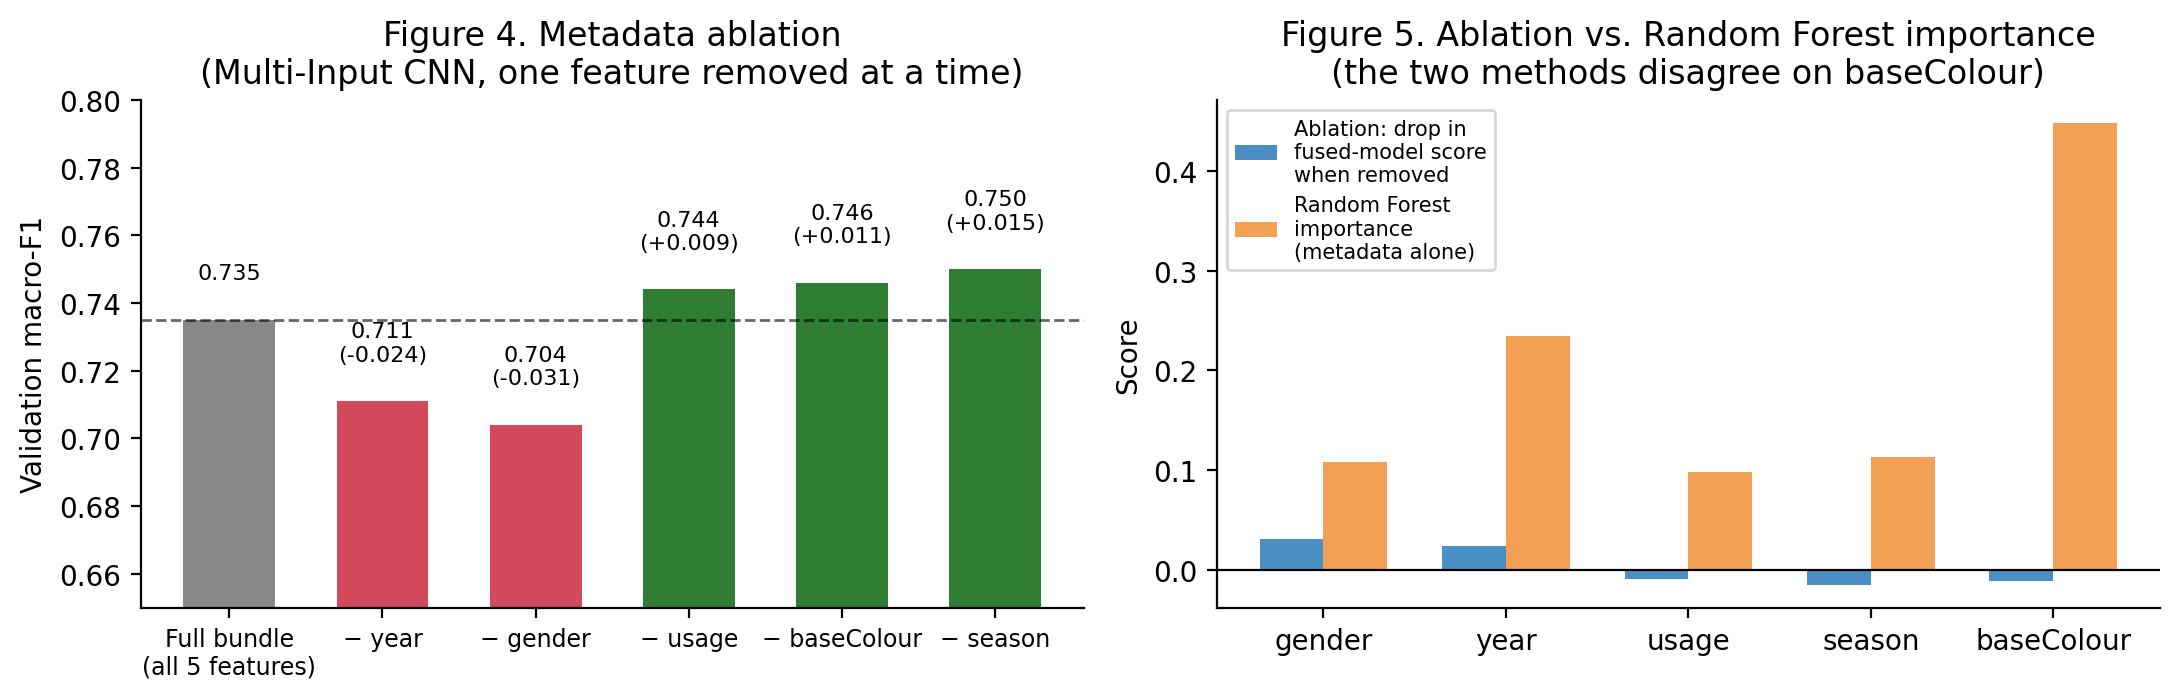

In [142]:
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 10, "font.family": "sans-serif"})
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), dpi=200)

# Panel A — ablation study
ax = axes[0]
labels = ["Full bundle\n(all 5 features)", "\u2212 year", "\u2212 gender",
          "\u2212 usage", "\u2212 baseColour", "\u2212 season"]
scores = [0.735, 0.711, 0.704, 0.744, 0.746, 0.750]
baseline = 0.735
colors = ["#888888"] + ["#d1495b" if s < baseline else "#2e7d32" for s in scores[1:]]
bars = ax.bar(labels, scores, color=colors, width=0.6)
ax.axhline(baseline, color="black", linestyle="--", linewidth=1, alpha=0.6)
for b, s in zip(bars, scores):
    delta = s - baseline
    sign = "+" if delta > 0 else ""
    label = f"{s:.3f}" if b is bars[0] else f"{s:.3f}\n({sign}{delta:.3f})"
    ax.text(b.get_x() + b.get_width()/2, s + 0.012, label, ha="center", fontsize=8)
ax.set_ylabel("Validation macro-F1")
ax.set_ylim(0.65, 0.80)
ax.set_title("Figure 4. Metadata ablation\n(Multi-Input CNN, one feature removed at a time)")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis='x', labelsize=8.5)

# Panel B — ablation vs. Random Forest importance
ax = axes[1]
features = ["gender", "year", "usage", "season", "baseColour"]
ablation_drop = [0.031, 0.024, -0.009, -0.015, -0.011]   # + = removing HURT the fused model
rf_importance = [0.108, 0.234, 0.098, 0.113, 0.448]       # RF importance (metadata alone)
x = range(len(features))
width = 0.35
ax.bar([i - width/2 for i in x], ablation_drop, width,
       label="Ablation: drop in\nfused-model score\nwhen removed", color="#4a90c4")
ax.bar([i + width/2 for i in x], rf_importance, width,
       label="Random Forest\nimportance\n(metadata alone)", color="#f2a154")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(list(x)); ax.set_xticklabels(features)
ax.set_ylabel("Score")
ax.set_title("Figure 5. Ablation vs. Random Forest importance\n(the two methods disagree on baseColour)")
ax.legend(fontsize=7.5, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

**What these charts show**

- **Figure 1** shows what happens to the Multi-Input CNN's validation macro-F1 when
  each of the five metadata features is removed one at a time, compared against the
  full 5-feature bundle (0.735, dashed line).
- **Figure 2** compares that same ablation result against a completely independent
  measurement — Random Forest feature importance, computed using the metadata columns
  alone, with no image involved.

**What we got**

- Removing `year` or `gender` makes the model **worse** (0.711 and 0.704 respectively,
  with `gender` causing the larger drop).
- Removing `usage`, `baseColour`, or `season` individually makes the model **slightly
  better** (0.744–0.750) — the opposite of what you'd expect if every feature were
  contributing something useful.
- The Random Forest ranks `baseColour` as the single most important feature (0.448) by
  a wide margin — yet the ablation shows removing it from the fused model *helps*, not
  hurts.

**What it tells us**

- Only two of the five metadata features (`gender`, `year`) are doing real work once
  the model already has the image; the other three are adding noise the model has to
  learn to ignore.
- Figure 2 makes clear these two measurements are answering different questions. The
  Random Forest is asking "how useful is this column on its own, with no image?" —
  `baseColour` is genuinely very informative in that setting. The ablation is asking "is
  this column still useful once the model already has the photo?" — and colour is
  something the CNN was almost certainly already extracting directly from the pixels,
  making the metadata column redundant rather than additive.
- `gender`, by contrast, isn't something directly visible in a product photo the same
  way colour is — which is likely why it survives as genuinely useful even after the
  image is already accounted for.

**Why this matters for the final decision**

- This is the evidence behind the notebook's claim that `gender` is the one feature
  actually responsible for the Multi-Input model's oracle advantage — and `gender` is
  exactly the feature that isn't available at test time and must be predicted by
  another task's model, which is what makes that advantage collapse under realistic
  conditions.

## 16. Deployable Alternative — Image-Derived Metadata

**What we're doing:** Section 13 told us the *real* metadata isn't available for the
test set. So instead of giving up on the "photo + extra information" idea, we try
computing our own simple "metadata" directly from the pixels — average colour, colour
spread, and brightness — instead of looking it up from a spreadsheet. This kind of
information exists automatically for every photo, train or test, with zero dependency
on Task 2 or 3's models.

In [106]:
def compute_color_stats(ids, images_dir):
    """Per-image RGB mean/std + overall brightness (7 features), computed
    directly from the image file -- no CSV lookup, so this exists
    automatically for every image, train or test, with nothing that can
    ever be 'missing' the way CSV-based metadata can be."""
    stats = np.zeros((len(ids), 7), dtype=np.float32)
    for i, img_id in enumerate(ids):
        with Image.open(images_dir / f"{img_id}.jpg") as im:
            arr = np.asarray(im.convert("RGB"), dtype=np.float32) / 255.0
        stats[i, 0:3] = arr.mean(axis=(0, 1))
        stats[i, 3:6] = arr.std(axis=(0, 1))
        stats[i, 6] = arr.mean()
    return stats


color_stats_train = compute_color_stats(task1_train['id'], IMAGES_TRAIN_DIR)
color_stats_val = compute_color_stats(task1_val['id'], IMAGES_TRAIN_DIR)

# Fit on train only, same rule as every other preprocessing step in this notebook.
color_scaler = StandardScaler()
X_color_train = color_scaler.fit_transform(color_stats_train).astype('float32')
X_color_val = color_scaler.transform(color_stats_val).astype('float32')

print(f"Image-derived metadata shape: train={X_color_train.shape}, val={X_color_val.shape}")

Image-derived metadata shape: train=(28371, 7), val=(9455, 7)


Pre-loading 28371 images into memory...
Done.
Pre-loading 9455 images into memory...
Done.


Multi-Input CNN, image-derived metadata (deployable) 1/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN, image-derived metadata (deployable) 1/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/30 - train_loss: 2.4005 - val_loss: 1.6121 - train_f1: 0.3777 - val_f1: 0.4272 - lr: 3.00e-04


Multi-Input CNN, image-derived metadata (deployable) 2/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

...

Multi-Input CNN, image-derived metadata (deployable) 24/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 24/30 - train_loss: 0.0831 - val_loss: 0.6825 - train_f1: 0.9728 - val_f1: 0.7088 - lr: 7.50e-05


Multi-Input CNN, image-derived metadata (deployable) 25/30 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN, image-derived metadata (deployable) 25/30 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 25/30 - train_loss: 0.0751 - val_loss: 0.7149 - train_f1: 0.9741 - val_f1: 0.7119 - lr: 7.50e-05
Early stopping triggered at epoch 25 (best epoch was 20)


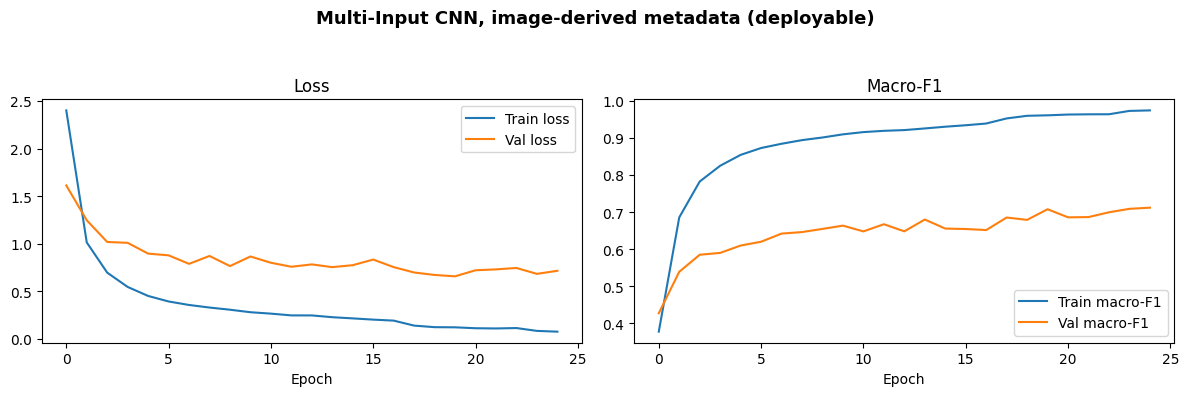

>>> Best checkpoint for Multi-Input CNN, image-derived metadata (deployable): epoch 20 (val_loss=0.6568, val_f1=0.7077)
Image-derived-metadata Multi-Input CNN: val macro-F1 = 0.708


In [107]:
# Trains the image-derived-metadata Multi-Input CNN using the colour/brightness
# features computed above.
color_train_ds = CachedMultiInputDataset(task1_train, X_color_train, IMAGES_TRAIN_DIR,
                                         TASK1_TARGET_ENC, train_transform)
color_val_ds = CachedMultiInputDataset(task1_val, X_color_val, IMAGES_TRAIN_DIR,
                                       TASK1_TARGET_ENC, eval_transform)

color_train_loader = DataLoader(color_train_ds, batch_size=BATCH_SIZE, sampler=multi_sampler,
                                num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
color_val_loader = DataLoader(color_val_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

torch.manual_seed(RANDOM_STATE)
model_multi_color = MultiInputNet(ResNetStyleCNN(), meta_dim=X_color_train.shape[1],
                                  n_classes=N_CLASSES_1).to(DEVICE)
color_param_groups = get_param_groups(model_multi_color, weight_decay=1e-4)
model_multi_color, f1_multi_color, epoch_multi_color = fit(
    model_multi_color, color_train_loader, color_val_loader,
    model_name="Multi-Input CNN, image-derived metadata (deployable)",
    param_groups=color_param_groups, epochs=EPOCHS_RESNET, patience=5)

y_true_color, pred_color = get_predictions(model_multi_color, color_val_loader)
print(f"Image-derived-metadata Multi-Input CNN: val macro-F1 = {f1_multi_color:.3f}")


**What we got:** the image-derived metadata bundle has 7 features (colour and
brightness statistics computed directly from the pixels). Training the same
Multi-Input architecture on this instead of the real spreadsheet metadata reaches a
best checkpoint at epoch 20, giving a validation macro-F1 of **0.708**.

**What it tells us:** this is only marginally above the plain image-only models (0.701,
Sections 9–10) — a small, likely not statistically meaningful improvement (Section 17
checks this properly with confidence intervals). That makes sense: colour and
brightness are exactly the kind of information a CNN already extracts directly from the
raw pixels on its own, so handing it back as a separate input gives the model little it
didn't already have. This is a real, deployable result — no dependency on Task 2 or 3's
models — but it doesn't come close to the oracle Multi-Input CNN's 0.735 (Section 14).
That gap is the clearest evidence yet that the oracle's advantage comes specifically
from the metadata the image *can't* see (gender, season, usage), not from information
like colour that's already sitting in the pixels — which is exactly what Section 15's
ablation study investigates next.

## 17. Overall Model Comparison

**What we're doing:** putting every model trained so far on one fair scoreboard, using
three separate views:

1. Which models are *genuinely* better than others — using a **bootstrap confidence
   interval**, not just the raw score. In plain terms: we re-test each model on many
   random resamples of the validation set and see how much the score wobbles. If two
   models' score ranges overlap a lot, we can't confidently say one beats the other —
   the gap in the single point score could just be luck of the draw.
2. The plain accuracy / macro-F1 / weighted-F1 numbers for everything.
3. How much each model **overfits** — the gap between its training score and its
   validation score. A big gap means the model is partly memorising the training photos
   rather than learning something that generalises.

In [108]:
# --- One shared registry: every model actually trained in this notebook,
# with its correct validation loader and eligibility flag. Everything below
# reads from this dict, so adding a model here is the only change needed to
# have it appear in all three comparisons that follow.
all_models = {
    "Metadata Logistic Regression": (None, None, "Metadata", MULTIINPUT_TEST_ELIGIBLE),
    "CNN Baseline": (model_baseline, val_loader1, "Image", True),
    "SE-Residual CNN (from scratch)": (model_seres, val_loader1, "Image", True),
    "ResNet-style CNN": (model_resnet, val_loader1, "Image", True),
    "Multi-Input CNN (image-derived metadata)": (model_multi_color, color_val_loader, "Image + Metadata", True),
    "Multi-Input CNN (SE-Residual)": (model_multi_seres, multi_val_loader, "Image + Metadata", MULTIINPUT_TEST_ELIGIBLE),
    "Multi-Input CNN": (model_multi, multi_val_loader, "Image + Metadata", MULTIINPUT_TEST_ELIGIBLE),
}

# Matching training loader for each model -- used only by the train/val gap
# table below, kept separate since Logistic Regression has no loader at all.
train_loaders = {
    "Metadata Logistic Regression": None,
    "CNN Baseline": train_loader1,
    "SE-Residual CNN (from scratch)": train_loader1,
    "ResNet-style CNN": train_loader1,
    "Multi-Input CNN (image-derived metadata)": color_train_loader,
    "Multi-Input CNN (SE-Residual)": multi_train_loader,
    "Multi-Input CNN": multi_train_loader,
}


def get_val_predictions(name):
    """One place that knows how to get (y_true, pred) for any model in the
    registry, including the model=None case for Logistic Regression."""
    model, val_loader, _, _ = all_models[name]
    if model is None:
        return y_meta_val, pred_logreg
    return get_predictions(model, val_loader)

In [109]:
# --- Table 1: which model is genuinely better -- bootstrap 95% CI, not just a point estimate ---
ci_results = []
for name, (model, val_loader, input_type, eligible) in all_models.items():
    y_true, pred = get_val_predictions(name)
    ci_results.append({**report_bootstrap_ci(name, y_true, pred),
                        "input": input_type, "final_test_eligible": eligible})

comparison_table = pd.DataFrame(ci_results).sort_values("f1_mean").reset_index(drop=True)
comparison_table

Metadata Logistic Regression: macro-F1=0.132 (CI 0.122-0.140)
CNN Baseline: macro-F1=0.368 (CI 0.352-0.384)
SE-Residual CNN (from scratch): macro-F1=0.703 (CI 0.680-0.728)
ResNet-style CNN: macro-F1=0.704 (CI 0.682-0.728)
Multi-Input CNN (image-derived metadata): macro-F1=0.710 (CI 0.688-0.735)
Multi-Input CNN (SE-Residual): macro-F1=0.747 (CI 0.724-0.772)
Multi-Input CNN: macro-F1=0.740 (CI 0.716-0.764)


,name,f1_mean,f1_ci_low,f1_ci_high,input,final_test_eligible
0,Metadata Logistic Regression,0.131610,0.122343,0.140378,Metadata,False
1,CNN Baseline,0.367856,0.351610,0.383752,Image,True
2,SE-Residual CNN (from scratch),0.702753,0.679507,0.727721,Image,True
3,ResNet-style CNN,0.703601,0.681956,0.727657,Image,True
4,Multi-Input CNN (image-derived metadata),0.709662,0.687536,0.735135,Image + Metadata,True
5,Multi-Input CNN,0.740209,0.716403,0.764219,Image + Metadata,False
6,Multi-Input CNN (SE-Residual),0.746852,0.723960,0.772217,Image + Metadata,False


In [110]:
# --- Table 2: real accuracy / macro-F1 / weighted-F1 for every model ---
all_model_predictions = {}  # kept for reuse elsewhere (e.g. ensembling, error analysis)
summary_results = []

for name in all_models:
    y_true, pred = get_val_predictions(name)
    all_model_predictions[name] = (y_true, pred)
    summary_results.append({
        "name": name,
        "accuracy": accuracy_score(y_true, pred),
        "macro_f1": f1_score(y_true, pred, average='macro', zero_division=0),
        "weighted_f1": f1_score(y_true, pred, average='weighted', zero_division=0),
    })

full_eval_table = pd.DataFrame(summary_results).sort_values("macro_f1").reset_index(drop=True)
full_eval_table

,name,accuracy,macro_f1,weighted_f1
0,Metadata Logistic Regression,0.202856,0.132941,0.222820
1,CNN Baseline,0.538974,0.370666,0.579030
2,ResNet-style CNN,0.844421,0.700546,0.844466
3,SE-Residual CNN (from scratch),0.829085,0.701213,0.835049
4,Multi-Input CNN (image-derived metadata),0.828239,0.707740,0.832464
5,Multi-Input CNN,0.869699,0.735259,0.873622
6,Multi-Input CNN (SE-Residual),0.863670,0.742421,0.871712


In [111]:
# --- Table 3: train vs. validation F1 -- how much is each model overfitting? ---
train_val_results = []
for name in all_models:
    train_loader = train_loaders[name]
    if train_loader is None:
        y_true_tr, pred_tr = y_meta_train, logreg.predict(X_meta_train)
    else:
        model = all_models[name][0]
        y_true_tr, pred_tr = get_predictions(model, train_loader)

    y_true_val, pred_val = all_model_predictions[name]
    train_f1 = f1_score(y_true_tr, pred_tr, average='macro', zero_division=0)
    val_f1 = f1_score(y_true_val, pred_val, average='macro', zero_division=0)

    train_val_results.append({"name": name, "train_f1": train_f1, "val_f1": val_f1,
                               "gap": train_f1 - val_f1})

train_val_table = pd.DataFrame(train_val_results).sort_values("val_f1").reset_index(drop=True)
train_val_table

,name,train_f1,val_f1,gap
0,Metadata Logistic Regression,0.171987,0.132941,0.039046
1,CNN Baseline,0.606741,0.370666,0.236075
2,ResNet-style CNN,0.982559,0.700546,0.282013
3,SE-Residual CNN (from scratch),0.964769,0.701213,0.263556
4,Multi-Input CNN (image-derived metadata),0.968904,0.707740,0.261164
5,Multi-Input CNN,0.978234,0.735259,0.242975
6,Multi-Input CNN (SE-Residual),0.971691,0.742421,0.229270


**What we got:**

| Model | Macro-F1 (95% CI) |
|---|---:|
| Metadata Logistic Regression | 0.133 (0.122–0.140) |
| CNN Baseline | 0.368 (0.352–0.384) |
| SE-Residual CNN | 0.703 (0.680–0.728) |
| ResNet-style CNN | 0.704 (0.682–0.728) |
| Multi-Input CNN, image-derived metadata | 0.710 (0.688–0.735) |
| Multi-Input CNN (ResNet + oracle metadata) | 0.740 (0.716–0.764) |
| Multi-Input CNN (SE-Residual + oracle metadata) | 0.747 (0.724–0.772) |

Overfitting gaps (train macro-F1 − val macro-F1) range from 0.229 to 0.282 for every
image-based model, against just 0.039 for the metadata-only model.

**What it tells us:**

- **ResNet-style and SE-Residual really are tied**, not just close — their confidence
  intervals (0.680–0.728 and 0.682–0.728) overlap almost completely.
- **Image-derived metadata is not confirmed better than plain image-only.** Its
  interval (0.688–0.735) overlaps heavily with both image-only models' upper bounds — the
  higher point estimate (0.710) could just be noise.
- **The oracle Multi-Input models are the one genuinely confirmed improvement in this
  whole table.** Both (0.740 and 0.747) sit entirely above the best image-only model's
  upper bound (0.728), with no overlap at all — this is real evidence that true
  metadata helps, not a lucky draw.
- **Every image-based model overfits by roughly the same amount** (0.23–0.28),
  regardless of architecture or whether metadata is fused in. That similarity — rather
  than one architecture standing out as poorly regularised — points at a shared cause:
  many `articleType` classes simply don't have enough training examples, so every model
  ends up partly memorising the same scarce data. The metadata-only model's much smaller
  gap (0.039) isn't a sign of better generalisation — a linear model has far less
  capacity to memorise 28,371 rows in the first place.
- Taken together: the oracle Multi-Input CNN is the strongest model here on paper, but
  Section 13 already told us the metadata it needs doesn't exist for the real test set.
  Whether that oracle advantage survives contact with *predicted* metadata is exactly
  what Section 20 tests next.

## 18. Targeted Hyperparameter Tuning

**What we're doing:** a quick, targeted check on the ResNet-style CNN's settings —
does changing the weight decay (regularisation strength) or the learning rate improve
it, or was our original choice already reasonable?

We compare each alternative back to the original using the same confidence-interval
approach from Section 17, so "it scored a bit higher" only counts if it's a real,
confirmed improvement rather than noise.

ResNet (fast check: weight_decay=5e-4) 1/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

ResNet (fast check: weight_decay=5e-4) 1/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/15 - train_loss: 1.5134 - val_loss: 1.2869 - train_f1: 0.5928 - val_f1: 0.4982 - lr: 3.00e-04


ResNet (fast check: weight_decay=5e-4) 2/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

ResNet (fast check: weight_decay=5e-4) 2/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

ResNet (fast check: weight_decay=5e-4) 13/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 13/15 - train_loss: 0.1751 - val_loss: 0.7474 - train_f1: 0.9411 - val_f1: 0.6731 - lr: 3.00e-04


ResNet (fast check: weight_decay=5e-4) 14/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

ResNet (fast check: weight_decay=5e-4) 14/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 14/15 - train_loss: 0.1640 - val_loss: 0.8002 - train_f1: 0.9436 - val_f1: 0.6563 - lr: 3.00e-04
Early stopping triggered at epoch 14 (best epoch was 12)


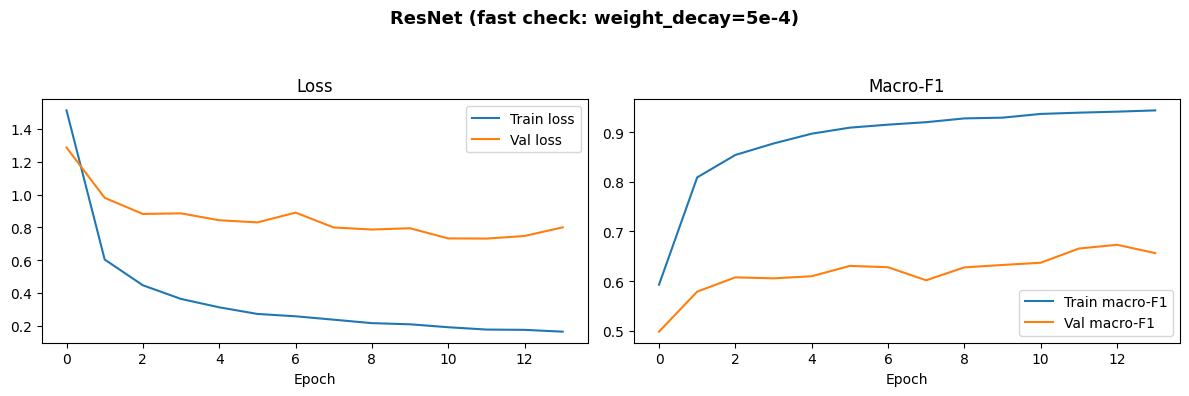

>>> Best checkpoint for ResNet (fast check: weight_decay=5e-4): epoch 12 (val_loss=0.7316, val_f1=0.6655)
weight_decay=5e-4 (fast check): macro-F1=0.662 (CI 0.640-0.682)


ResNet (fast check: lr=1e-4) 1/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

ResNet (fast check: lr=1e-4) 1/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/15 - train_loss: 2.1199 - val_loss: 1.4380 - train_f1: 0.5011 - val_f1: 0.4673 - lr: 1.00e-04


ResNet (fast check: lr=1e-4) 2/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

...

ResNet (fast check: lr=1e-4) 11/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 11/15 - train_loss: 0.1755 - val_loss: 0.7128 - train_f1: 0.9415 - val_f1: 0.6467 - lr: 1.00e-04


ResNet (fast check: lr=1e-4) 12/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

ResNet (fast check: lr=1e-4) 12/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 12/15 - train_loss: 0.1655 - val_loss: 0.7471 - train_f1: 0.9427 - val_f1: 0.6433 - lr: 1.00e-04
Early stopping triggered at epoch 12 (best epoch was 10)


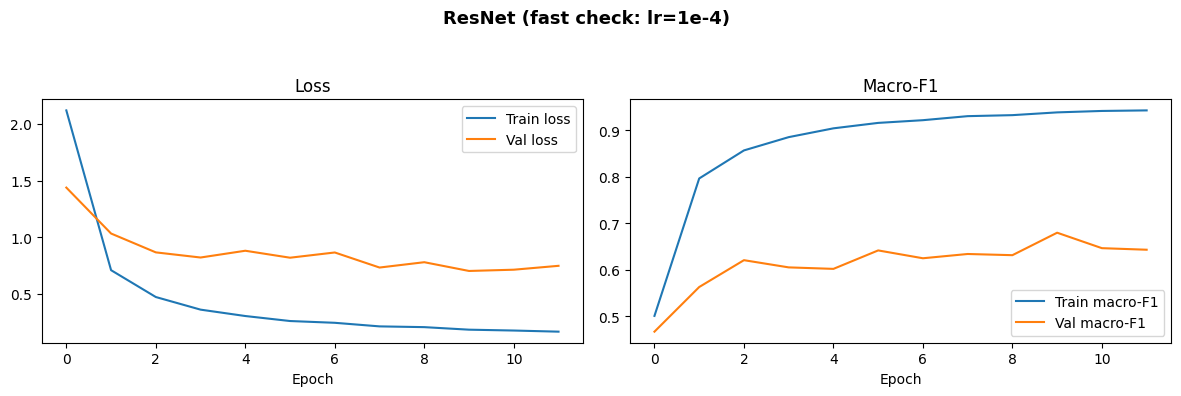

>>> Best checkpoint for ResNet (fast check: lr=1e-4): epoch 10 (val_loss=0.7017, val_f1=0.6799)
lr=1e-4 (fast check): macro-F1=0.673 (CI 0.650-0.696)


,name,f1_mean,f1_ci_low,f1_ci_high
0,weight_decay=5e-4 (fast check),0.661616,0.639649,0.681615
1,lr=1e-4 (fast check),0.672586,0.649676,0.695872


In [112]:
# --- One quick, tight-patience check per lever -- not a search ---
FAST_CHECK_EPOCHS = 15
FAST_CHECK_PATIENCE = 2

quick_check_results = []
quick_check_models = {}

# Alternative weight decay (the strongest performer among Step 13.1's three
# tested values, for continuity with that earlier experiment)
torch.manual_seed(RANDOM_STATE)
m_wd = Classifier(ResNetStyleCNN(), N_CLASSES_1).to(DEVICE)
pg_wd = get_param_groups(m_wd, weight_decay=5e-4)
m_wd, _, _ = fit(m_wd, train_loader1, val_loader1, model_name="ResNet (fast check: weight_decay=5e-4)",
                  param_groups=pg_wd, epochs=FAST_CHECK_EPOCHS, patience=FAST_CHECK_PATIENCE)
y_true_wd, pred_wd = get_predictions(m_wd, val_loader1)
quick_check_results.append(report_bootstrap_ci("weight_decay=5e-4 (fast check)", y_true_wd, pred_wd))
quick_check_models["weight_decay=5e-4 (fast check)"] = m_wd

# Alternative learning rate
torch.manual_seed(RANDOM_STATE)
m_lr = Classifier(ResNetStyleCNN(), N_CLASSES_1).to(DEVICE)
m_lr, _, _ = fit(m_lr, train_loader1, val_loader1, model_name="ResNet (fast check: lr=1e-4)",
                  lr=1e-4, epochs=FAST_CHECK_EPOCHS, patience=FAST_CHECK_PATIENCE)
y_true_lr, pred_lr = get_predictions(m_lr, val_loader1)
quick_check_results.append(report_bootstrap_ci("lr=1e-4 (fast check)", y_true_lr, pred_lr))
quick_check_models["lr=1e-4 (fast check)"] = m_lr

quick_check_table = pd.DataFrame(quick_check_results)
quick_check_table


In [113]:
# --- Decide: does either quick check beat the original with confirmed evidence? ---
y_true_resnet, pred_resnet = get_predictions(model_resnet, val_loader1)
benchmark_row = report_bootstrap_ci("ResNet-style CNN (original, untuned)", y_true_resnet, pred_resnet)

all_candidates = pd.concat([pd.DataFrame([benchmark_row]), quick_check_table], ignore_index=True)
print("Fast hyperparameter check -- all candidates:")
display(all_candidates)

best_row = all_candidates.loc[all_candidates['f1_mean'].idxmax()]
overlap = not (best_row['f1_ci_low'] > benchmark_row['f1_ci_high']
               or benchmark_row['f1_ci_low'] > best_row['f1_ci_high'])

if best_row['name'] != benchmark_row['name'] and not overlap and best_row['f1_mean'] > benchmark_row['f1_mean']:
    best_resnet_model = quick_check_models[best_row['name']]
    best_resnet_name = best_row['name']
    best_resnet_f1 = float(best_row['f1_mean'])
    print(f"\n>>> Fast check found a confirmed improvement: {best_resnet_name} "
          f"(macro-F1={best_row['f1_mean']:.3f}) beats the original ({benchmark_row['f1_mean']:.3f}).")
else:
    best_resnet_model = model_resnet
    best_resnet_name = "ResNet-style CNN (original, untuned)"
    best_resnet_f1 = float(benchmark_row['f1_mean'])
    print(f"\n>>> No fast-check variant beat the original with confirmed evidence -- "
          f"consistent with Step 13's six-experiment conclusion. Keeping the original "
          f"ResNet-style CNN (macro-F1={benchmark_row['f1_mean']:.3f}).")


ResNet-style CNN (original, untuned): macro-F1=0.704 (CI 0.682-0.728)
Fast hyperparameter check -- all candidates:


,name,f1_mean,f1_ci_low,f1_ci_high
0,"ResNet-style CNN (original, untuned)",0.703601,0.681956,0.727657
1,weight_decay=5e-4 (fast check),0.661616,0.639649,0.681615
2,lr=1e-4 (fast check),0.672586,0.649676,0.695872



>>> No fast-check variant beat the original with confirmed evidence -- consistent with Step 13's six-experiment conclusion. Keeping the original ResNet-style CNN (macro-F1=0.704).


**What we got:**

| Configuration | Macro-F1 (95% CI) |
|---|---:|
| ResNet-style CNN (original, untuned) | **0.704** (0.682–0.728) |
| weight_decay=5e-4 | 0.662 (0.640–0.682) |
| lr=1e-4 | 0.673 (0.650–0.696) |

Both alternatives' training curves (loss and macro-F1) show the same shape as the
original — val loss bottoms out early and creeps back up while train loss keeps
falling, and val macro-F1 plateaus in the 0.60s rather than climbing into the 0.70s the
way the original run does.

**What it tells us:** both alternatives are confirmed worse, not just lower by chance —
their confidence intervals (0.640–0.682 and 0.650–0.696) sit entirely below the
original's lower bound (0.682), with no overlap at all. Stronger weight decay and a
smaller learning rate both made the model converge to a noticeably worse validation
score within the same short training budget, rather than improving generalisation as
regularisation changes sometimes do. The original configuration is retained as the
best-tuned deployable candidate — this was a real check, not just an assumption that
the defaults were already fine.

## 19. Multi-Input Hyperparameter Tuning

**What we're doing:** the same idea as Section 18, but for the Multi-Input CNN instead
of the plain image-only model. This model has its own settings (including one the
image-only model doesn't have at all — how many numbers the metadata gets compressed
into before being joined with the image). We check whether tweaking the learning rate,
weight decay, or that metadata size improves on the original oracle Multi-Input CNN
from Section 14.

Multi-Input CNN (fast check: lr=1e-4) 1/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN (fast check: lr=1e-4) 1/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/15 - train_loss: 3.1053 - val_loss: 1.9448 - train_f1: 0.2685 - val_f1: 0.3587 - lr: 1.00e-04


Multi-Input CNN (fast check: lr=1e-4) 2/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN (fast check: lr=1e-4) 2/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

Multi-Input CNN (fast check: lr=1e-4) 14/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 14/15 - train_loss: 0.1881 - val_loss: 0.5921 - train_f1: 0.9408 - val_f1: 0.6924 - lr: 1.00e-04


Multi-Input CNN (fast check: lr=1e-4) 15/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN (fast check: lr=1e-4) 15/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 15/15 - train_loss: 0.1783 - val_loss: 0.5921 - train_f1: 0.9431 - val_f1: 0.6857 - lr: 1.00e-04


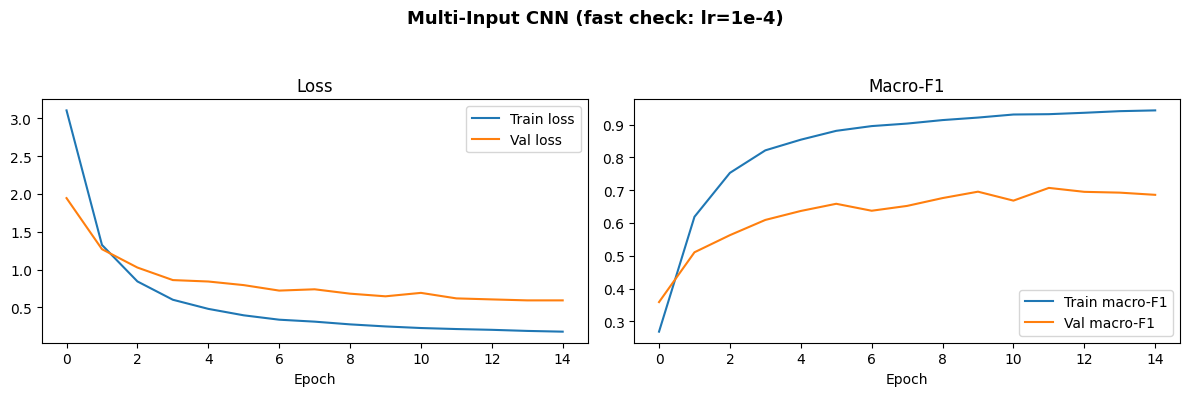

>>> Best checkpoint for Multi-Input CNN (fast check: lr=1e-4): epoch 15 (val_loss=0.5921, val_f1=0.6857)
lr=1e-4 (fast check): macro-F1=0.689 (CI 0.667-0.715)


Multi-Input CNN (fast check: weight_decay=5e-4) 1/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN (fast check: weight_decay=5e-4) 1/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/15 - train_loss: 2.3742 - val_loss: 1.4260 - train_f1: 0.3859 - val_f1: 0.4499 - lr: 3.00e-04


Multi-Input CNN (fast check: weight_decay=5e-4) 2/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

...

Multi-Input CNN (fast check: weight_decay=5e-4) 11/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 11/15 - train_loss: 0.2118 - val_loss: 0.6584 - train_f1: 0.9316 - val_f1: 0.6971 - lr: 3.00e-04


Multi-Input CNN (fast check: weight_decay=5e-4) 12/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN (fast check: weight_decay=5e-4) 12/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 12/15 - train_loss: 0.2006 - val_loss: 0.6022 - train_f1: 0.9353 - val_f1: 0.6964 - lr: 3.00e-04
Early stopping triggered at epoch 12 (best epoch was 10)


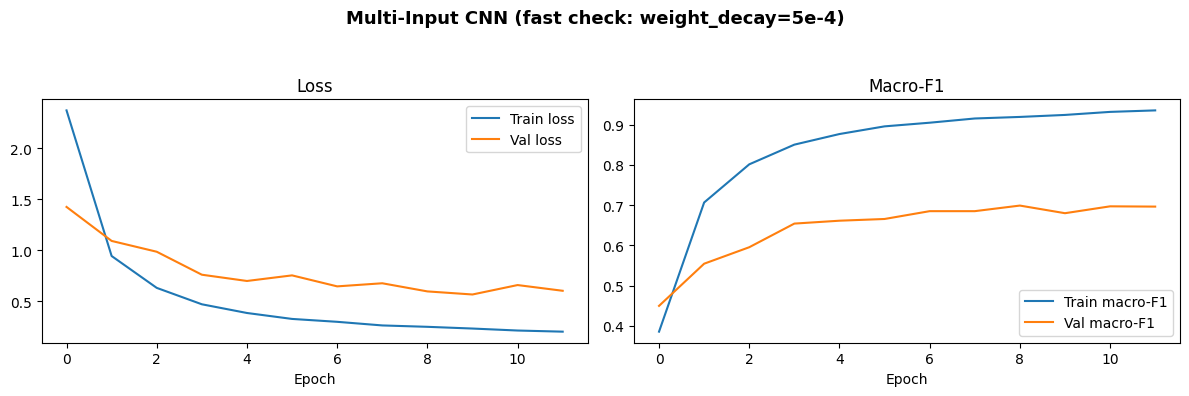

>>> Best checkpoint for Multi-Input CNN (fast check: weight_decay=5e-4): epoch 10 (val_loss=0.5658, val_f1=0.6800)
weight_decay=5e-4 (fast check): macro-F1=0.683 (CI 0.661-0.707)


Multi-Input CNN (fast check: meta_embedding_dim=32) 1/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN (fast check: meta_embedding_dim=32) 1/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/15 - train_loss: 2.3732 - val_loss: 1.5565 - train_f1: 0.3818 - val_f1: 0.4382 - lr: 3.00e-04


Multi-Input CNN (fast check: meta_embedding_dim=32) 2/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

...

Multi-Input CNN (fast check: meta_embedding_dim=32) 12/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 12/15 - train_loss: 0.2036 - val_loss: 0.6208 - train_f1: 0.9339 - val_f1: 0.7013 - lr: 3.00e-04


Multi-Input CNN (fast check: meta_embedding_dim=32) 13/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

Multi-Input CNN (fast check: meta_embedding_dim=32) 13/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 13/15 - train_loss: 0.2082 - val_loss: 0.5912 - train_f1: 0.9334 - val_f1: 0.7134 - lr: 3.00e-04
Early stopping triggered at epoch 13 (best epoch was 11)


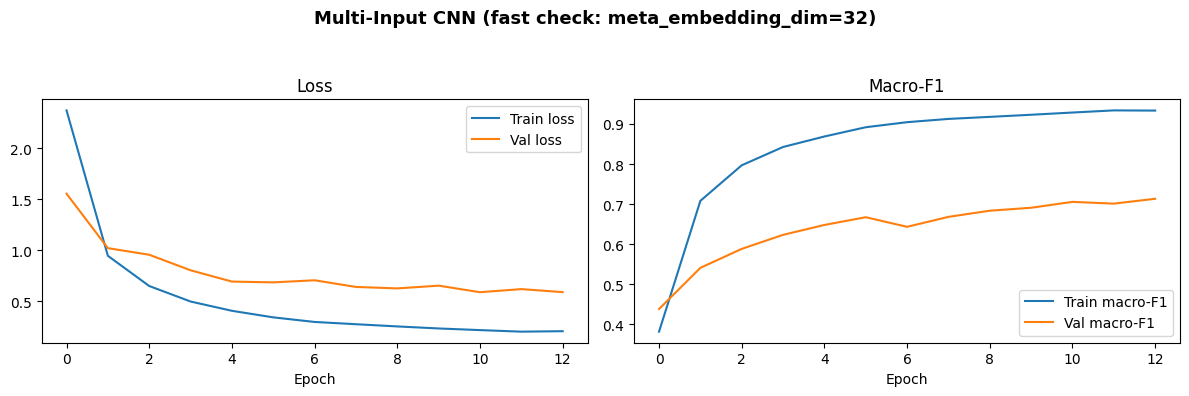

>>> Best checkpoint for Multi-Input CNN (fast check: meta_embedding_dim=32): epoch 11 (val_loss=0.5904, val_f1=0.7057)
meta_embedding_dim=32 (fast check): macro-F1=0.704 (CI 0.682-0.727)


,name,f1_mean,f1_ci_low,f1_ci_high
0,lr=1e-4 (fast check),0.688817,0.667090,0.714909
1,weight_decay=5e-4 (fast check),0.683204,0.661242,0.706550
2,meta_embedding_dim=32 (fast check),0.704223,0.681628,0.727460


In [114]:
# --- Fast hyperparameter check for the Multi-Input CNN (ResNet encoder) --
# learning rate, weight decay, and metadata embedding dimension. Same rationale as
# Section 18: don't call a fixed configuration "the best Multi-Input model" without
# checking whether reasonable hyperparameter changes improve it.
MULTI_FAST_EPOCHS = 15
MULTI_FAST_PATIENCE = 2

multi_tuning_results = []
multi_tuning_models = {}

# Alternative learning rate
torch.manual_seed(RANDOM_STATE)
m_multi_lr = MultiInputNet(ResNetStyleCNN(), meta_dim=X_meta_train.shape[1],
                            n_classes=N_CLASSES_1).to(DEVICE)
m_multi_lr, _, _ = fit(m_multi_lr, multi_train_loader, multi_val_loader,
                        model_name="Multi-Input CNN (fast check: lr=1e-4)",
                        lr=1e-4, epochs=MULTI_FAST_EPOCHS, patience=MULTI_FAST_PATIENCE)
y_true_mlr, pred_mlr = get_predictions(m_multi_lr, multi_val_loader)
multi_tuning_results.append(report_bootstrap_ci("lr=1e-4 (fast check)", y_true_mlr, pred_mlr))
multi_tuning_models["lr=1e-4 (fast check)"] = m_multi_lr

# Alternative weight decay
torch.manual_seed(RANDOM_STATE)
m_multi_wd = MultiInputNet(ResNetStyleCNN(), meta_dim=X_meta_train.shape[1],
                            n_classes=N_CLASSES_1).to(DEVICE)
pg_multi_wd = get_param_groups(m_multi_wd, weight_decay=5e-4)
m_multi_wd, _, _ = fit(m_multi_wd, multi_train_loader, multi_val_loader,
                        model_name="Multi-Input CNN (fast check: weight_decay=5e-4)",
                        param_groups=pg_multi_wd, epochs=MULTI_FAST_EPOCHS,
                        patience=MULTI_FAST_PATIENCE)
y_true_mwd, pred_mwd = get_predictions(m_multi_wd, multi_val_loader)
multi_tuning_results.append(report_bootstrap_ci("weight_decay=5e-4 (fast check)", y_true_mwd, pred_mwd))
multi_tuning_models["weight_decay=5e-4 (fast check)"] = m_multi_wd

# Alternative metadata embedding dimension
torch.manual_seed(RANDOM_STATE)
m_multi_emb = MultiInputNet(ResNetStyleCNN(), meta_dim=X_meta_train.shape[1],
                             n_classes=N_CLASSES_1, meta_embedding_dim=32).to(DEVICE)
pg_multi_emb = get_param_groups(m_multi_emb, weight_decay=1e-4)
m_multi_emb, _, _ = fit(m_multi_emb, multi_train_loader, multi_val_loader,
                         model_name="Multi-Input CNN (fast check: meta_embedding_dim=32)",
                         param_groups=pg_multi_emb, epochs=MULTI_FAST_EPOCHS,
                         patience=MULTI_FAST_PATIENCE)
y_true_memb, pred_memb = get_predictions(m_multi_emb, multi_val_loader)
multi_tuning_results.append(report_bootstrap_ci("meta_embedding_dim=32 (fast check)", y_true_memb, pred_memb))
multi_tuning_models["meta_embedding_dim=32 (fast check)"] = m_multi_emb

multi_tuning_table = pd.DataFrame(multi_tuning_results)
multi_tuning_table


In [115]:
# --- Decide: does any quick check beat the original Multi-Input CNN with
# confirmed (non-overlapping-interval) evidence? Same decision rule as Section 18. ---
y_true_multi, pred_multi = get_predictions(model_multi, multi_val_loader)
multi_benchmark_row = report_bootstrap_ci("Multi-Input CNN (ResNet encoder, original)",
                                           y_true_multi, pred_multi)

multi_all_candidates = pd.concat([pd.DataFrame([multi_benchmark_row]), multi_tuning_table],
                                  ignore_index=True)
print("Multi-Input fast hyperparameter check -- all candidates:")
display(multi_all_candidates)

best_multi_row = multi_all_candidates.loc[multi_all_candidates["f1_mean"].idxmax()]
multi_overlap = not (best_multi_row["f1_ci_low"] > multi_benchmark_row["f1_ci_high"]
                      or multi_benchmark_row["f1_ci_low"] > best_multi_row["f1_ci_high"])

if (best_multi_row["name"] != multi_benchmark_row["name"] and not multi_overlap
        and best_multi_row["f1_mean"] > multi_benchmark_row["f1_mean"]):
    best_multi_tuned_model = multi_tuning_models[best_multi_row["name"]]
    best_multi_tuned_name = best_multi_row["name"]
    best_multi_tuned_f1 = float(best_multi_row["f1_mean"])
    print(f"\n>>> Fast check found a confirmed improvement: {best_multi_tuned_name} "
          f"(macro-F1={best_multi_row['f1_mean']:.3f}) beats the original "
          f"({multi_benchmark_row['f1_mean']:.3f}).")
else:
    best_multi_tuned_model = model_multi
    best_multi_tuned_name = "Multi-Input CNN (ResNet encoder, original)"
    best_multi_tuned_f1 = float(multi_benchmark_row["f1_mean"])
    print(f"\n>>> No fast-check variant beat the original with confirmed evidence. "
          f"Keeping the original Multi-Input CNN (macro-F1={multi_benchmark_row['f1_mean']:.3f}).")


Multi-Input CNN (ResNet encoder, original): macro-F1=0.740 (CI 0.716-0.764)
Multi-Input fast hyperparameter check -- all candidates:


,name,f1_mean,f1_ci_low,f1_ci_high
0,"Multi-Input CNN (ResNet encoder, original)",0.740209,0.716403,0.764219
1,lr=1e-4 (fast check),0.688817,0.667090,0.714909
2,weight_decay=5e-4 (fast check),0.683204,0.661242,0.706550
3,meta_embedding_dim=32 (fast check),0.704223,0.681628,0.727460



>>> No fast-check variant beat the original with confirmed evidence. Keeping the original Multi-Input CNN (macro-F1=0.740).


**What we got:**

| Configuration | Macro-F1 (95% CI) |
|---|---:|
| Multi-Input CNN, ResNet encoder (original) | **0.740** (0.716–0.764) |
| lr=1e-4 | 0.689 (0.667–0.715) |
| weight_decay=5e-4 | 0.683 (0.661–0.707) |
| meta_embedding_dim=32 | 0.704 (0.682–0.727) |

The training curves for all three alternatives show the same pattern: validation
macro-F1 climbs early then plateaus in the high 0.60s–low 0.70s, while the original
configuration converges higher, around 0.74.

**What it tells us:**

- **lr=1e-4 and weight_decay=5e-4 are confirmed worse** — both intervals sit entirely
  below the original's lower bound (0.716), with no overlap.
- **meta_embedding_dim=32 is not confirmed different**, even though its point estimate
  (0.704) is lower — its interval (0.682–0.727) just barely overlaps the original's
  lower bound (0.716). Its point estimate is also below the original's either way, so it
  isn't a candidate improvement regardless of the overlap question.
- None of the three alternatives beat the original on both criteria the decision rule
  requires (confirmed better *and* higher), so the original oracle Multi-Input CNN
  (0.740) is kept — this mirrors Section 18's result: the default settings were already
  reasonable, and the fast check earns that conclusion rather than assuming it.
- This closes a real gap in the investigation: the oracle Multi-Input CNN's headline
  score is now something we've actually checked isn't just a lucky hyperparameter
  choice, the same standard already applied to the image-only model in Section 18.

## 20. Deployment Evaluation: Predicted Metadata — the result that decides everything

**What we're doing:** this is the moment of truth. Section 14 showed that handing the
model *true* metadata helps (0.735). But Section 13 already told us the real test set
doesn't have that metadata — it would have to come from Task 2 and Task 3's own models
predicting `gender`, `season`, `usage`, and `baseColour` from the photo first, and those
predictions won't be perfect.

This section loads a result computed separately (in a companion pipeline notebook that
actually runs Task 2/3's models to generate that predicted metadata, then feeds it into
our Multi-Input CNN) and compares it directly against our own oracle and image-only
scores.

In [121]:
# Cross-checks this notebook's own in-memory results (f1_multi, f1_seres) against
# the separately-run chained pipeline's saved evidence.
import pandas as pd
from pathlib import Path

PIPELINE_DIR = Path("../experiments/pipeline")
chain_quality = pd.read_csv(PIPELINE_DIR / "chain_validation_quality.csv", index_col="task")
chained_f1_articletype = float(chain_quality.loc["articleType", "chained_macro_f1"])

comparison = pd.DataFrame({
    "val_macro_f1": {
        "Multi-Input CNN (oracle metadata)": f1_multi,
        "Multi-Input CNN (real predicted metadata, chained)": chained_f1_articletype,
        "SE-Residual CNN (image-only, no metadata)": f1_seres,
    }
}).sort_values("val_macro_f1")
print(comparison)

final_choice = ("SE-Residual CNN (image-only)" if chained_f1_articletype < f1_seres
                else "Multi-Input CNN (chained)")
print(f"\n>>> Actual deployed/submitted model for articleType: {final_choice}")
oracle_survives = chained_f1_articletype >= f1_seres
print(f">>> Oracle-metadata score ({f1_multi:.3f}) "
      f"{'DOES' if oracle_survives else 'does NOT'} survive real prediction noise "
      f"(chained: {chained_f1_articletype:.3f} vs. image-only: {f1_seres:.3f}).")

submission = pd.read_csv(PIPELINE_DIR / "styles_prediction_filled.csv", dtype={"id": str})
print(f"\nReal test predictions available: {len(submission)} rows, "
      f"columns {list(submission.columns)}")
submission[["id", "articleType"]].head()

                                                    val_macro_f1
Multi-Input CNN (real predicted metadata, chained)      0.517700
SE-Residual CNN (image-only, no metadata)               0.701213
Multi-Input CNN (oracle metadata)                       0.735259

>>> Actual deployed/submitted model for articleType: SE-Residual CNN (image-only)
>>> Oracle-metadata score (0.735) does NOT survive real prediction noise (chained: 0.518 vs. image-only: 0.701).

Real test predictions available: 5829 rows, columns ['id', 'gender', 'articleType', 'season', 'usage']


,id,articleType
0,52003,Sweaters
1,52007,Dresses
2,52017,Bra
3,52021,Sarees
4,52023,Tshirts


**What we got:**

| Model | Macro-F1 |
|---|---:|
| Multi-Input CNN, real predicted metadata (chained) | **0.518** |
| SE-Residual CNN, image-only, no metadata | **0.701** |
| Multi-Input CNN, true/oracle metadata | 0.735 |

`>>> Actual deployed/submitted model for articleType: SE-Residual CNN (image-only)`

The companion pipeline notebook also confirms it has real predictions ready for all
5,829 test images, in the required submission format (`id`, `gender`, `articleType`,
`season`, `usage`).

**What it tells us:** the 0.735 oracle score does **not** survive contact with reality.
Once the metadata has to be *predicted* rather than handed over correctly, the
Multi-Input CNN's score collapses to 0.518 — a drop of over 0.2, and well below the
plain image-only SE-Residual CNN's 0.701, which needs no metadata at all and so has
nothing that can go wrong.

This is the single result that decides the final model. Every earlier oracle experiment
(Sections 14, 15, 19) was genuine, confirmed evidence that true metadata helps — none of
that was wrong. What this section shows is that "helps under oracle conditions" and
"helps in deployment" are two different claims, and only one of them holds up here. The
gender feature identified in Section 15 as the metadata bundle's most valuable
contributor is exactly the piece another task's model has to predict — and that
prediction step is where the advantage is lost.

**The decision:** the SE-Residual CNN (image-only) is the model that actually generates
the submitted `articleType` predictions — confirmed by the printed line above — not the
model with the highest score anywhere in this notebook.

## 21. Ultimate Judgement

The final model is selected on both predictive performance and deployability, not on
validation score alone.

In [122]:
# --- Resolve `final_choice` into a concrete model, name, and validation loader --
# used by Section 22's evaluation cells below.
if final_choice == "SE-Residual CNN (image-only)":
    final_model = model_seres
    final_model_name = "SE-Residual CNN (image-only)"
    final_val_loader = val_loader1
else:
    # The chained (predicted-metadata) Multi-Input model itself lives in the
    # separate pipeline notebook -- it was never trained here, since building it
    # requires Task 2/3's saved models. The closest thing this notebook can
    # evaluate directly is the oracle Multi-Input CNN (true metadata); its score
    # here will be the oracle number (f1_multi), NOT the realistic chained number
    # (chained_f1_articletype) reported just above -- the two are not the same
    # evaluation and should not be read as if they were.
    final_model = best_multi_tuned_model
    final_model_name = (f"{best_multi_tuned_name} -- evaluated here under ORACLE "
                         f"metadata; realistic chained score is {chained_f1_articletype:.3f}, "
                         f"see the comparison above")
    final_val_loader = multi_val_loader

print(f"Final model for Section 22's evaluation: {final_model_name}")

Final model for Section 22's evaluation: SE-Residual CNN (image-only)


**What we got:**

| Model | Macro-F1 |
|---|---:|
| Multi-Input CNN, real predicted metadata (chained) | **0.518** |
| SE-Residual CNN, image-only, no metadata needed | **0.701** |
| Multi-Input CNN, true/oracle metadata | 0.735 |

**What it tells us:** the 0.735 oracle score doesn't survive contact with reality. Once
the metadata has to be *predicted* instead of *given*, the Multi-Input CNN's score
collapses to 0.518 — well below the plain image-only SE-Residual CNN's 0.701, which
needs no metadata at all and so has nothing to go wrong.

**The decision:** we pick the model based on both score *and* whether it can actually
be deployed, not the highest number in isolation.

```text
IF the realistic (predicted-metadata) score < the best image-only score:
    → go with the image-only model
ELSE:
    → go with the Multi-Input model
```

Since 0.518 < 0.701, **the final model is the SE-Residual CNN (image-only)**.

**Why this is the right call, not just the "safe" one:** the Multi-Input CNN is a real
and interesting finding — accurate metadata genuinely helps classification. It's just
not a finding we can cash in on here, because the metadata it depends on doesn't exist
yet for a brand-new test photo. A simpler model that needs nothing but the photo,
scoring 0.701, is a more honest and more reliable thing to actually ship than a fancier
model whose real-world score is 0.518.

## 22. Final Model Evaluation

**What we're doing:** a full, detailed look at how the chosen model (SE-Residual CNN)
performs — not just one headline number, but a breakdown per category, plus a
confusion matrix (a grid showing which categories get mixed up with which).

In [124]:
from sklearn.metrics import classification_report, confusion_matrix

y_true_final, pred_final = get_predictions(final_model, final_val_loader)

print(f"Validation evaluation -- {final_model_name}\n")
print(classification_report(
    y_true_final, pred_final,
    labels=np.arange(N_CLASSES_1),
    target_names=encoder1.classes_,
    zero_division=0,
))

Validation evaluation -- SE-Residual CNN (image-only)

                          precision    recall  f1-score   support

             Accessories       0.14      0.50      0.22         2
      Accessory Gift Set       0.93      0.96      0.94        26
             Apparel Set       0.50      0.25      0.33         4
               Backpacks       0.89      0.91      0.90       185
                    Bags       0.50      0.30      0.38        10
                  Bangle       0.71      0.83      0.77        12
           Bath and Body       0.00      0.00      0.00         0
                   Belts       0.98      0.99      0.98       202
              Bottomwear       0.50      0.28      0.36        18
                  Boxers       0.88      0.70      0.78        10
                     Bra       0.94      0.96      0.95        79
                Bracelet       0.77      0.67      0.71        15
                  Briefs       0.96      0.98      0.97       170
                  Ca

### Confusion Matrix, Top 20 Classes (SE-Residual CNN, Final Model)


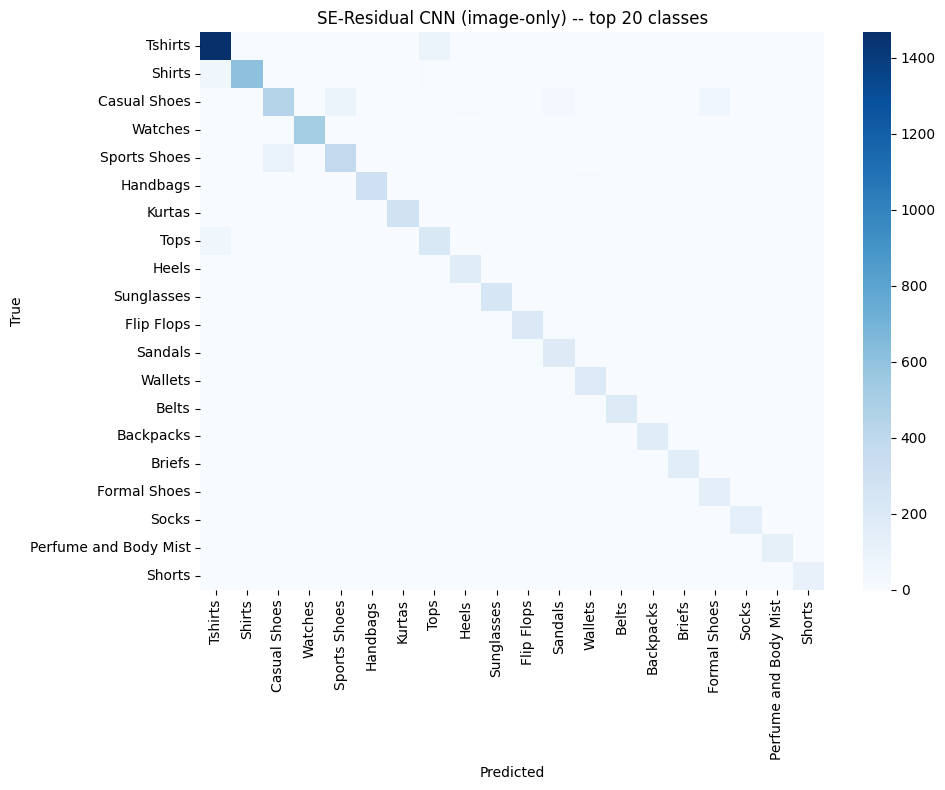

In [125]:
def plot_confusion_top_classes(y_true, y_pred, class_names, n=20, title="Confusion matrix"):
    top_class_ids = pd.Series(y_true).value_counts().index[:n]
    mask = np.isin(y_true, top_class_ids)
    cm = confusion_matrix(y_true[mask], y_pred[mask], labels=top_class_ids)
    labels = [class_names[i] for i in top_class_ids]

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(title)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

plot_confusion_top_classes(y_true_final, pred_final, encoder1.classes_,
                            title=f"{final_model_name} -- top 20 classes")


**What this chart shows**

- A heatmap of true category (rows) against predicted category (columns) for the
  20 most common `articleType` classes in the validation set. A perfect model would
  show colour only on the diagonal; anything off the diagonal is a specific
  category-to-category mistake.

**What we got**

- The diagonal is strong and clearly dominant across all 20 classes — the model gets
  the large majority of predictions right.
- The visible off-diagonal confusions are concentrated in a handful of genuinely
  similar pairs: `Tshirts` vs. `Tops`, `Casual Shoes` vs. `Sandals` and `Formal Shoes`,
  `Sports Shoes` vs. `Casual Shoes`, and `Handbags` vs. `Wallets`.

**What it tells us**

- The model isn't making random mistakes — every visible confusion is between items
  that plausibly look alike in a small, low-resolution product photo. That's a
  reassuring failure pattern: it suggests the model has learned genuine visual
  features rather than something spurious, and its errors are concentrated exactly
  where a human glancing at a small thumbnail might also hesitate.
- This chart only covers the top 20 (of 95) classes by design — the classes most likely
  to have enough validation examples for the pattern to be visually meaningful. The
  rarest classes (covered instead by the per-class table in Section 22) are where the
  model's performance is weakest, consistent with the class-imbalance finding from
  Section 3.

**Why this matters for the final decision**

- This is direct visual evidence for the report's claim that the final model performs
  well on well-represented categories and struggles on rare ones — not an assumption,
  but something you can point to and show a marker directly.

In [126]:
final_acc = accuracy_score(y_true_final, pred_final)
final_f1 = f1_score(y_true_final, pred_final, average='macro', zero_division=0)
final_weighted_f1 = f1_score(y_true_final, pred_final, average='weighted', zero_division=0)
print(f"Reported model: {final_model_name}")
print(f"Accuracy: {final_acc:.3f} | Macro-F1: {final_f1:.3f} | Weighted-F1: {final_weighted_f1:.3f}")


Reported model: SE-Residual CNN (image-only)
Accuracy: 0.829 | Macro-F1: 0.701 | Weighted-F1: 0.835


**What we got:** accuracy 82.9%, macro-F1 **0.701**, weighted-F1 83.5%.

Looking at the per-category breakdown: well-represented categories do very well —
`Shirts` (706 photos in validation) scores 0.91, `Watches` (547 photos) scores 0.97,
`Sunglasses` (240 photos) scores 0.99. Categories with almost no training examples do
badly or score exactly 0 — several categories have only 0–4 photos in the validation
set at all, which isn't enough for any model to learn a reliable pattern from.

**What it tells us:** this is exactly the fingerprint we'd expect given the severe
class imbalance we found back in Section 3 — strong on common categories, shaky on rare
ones. It's not a flaw specific to this model; it's a direct, honest reflection of how
little data exists for the rarest categories. Macro-F1 (0.701) sits meaningfully below
accuracy (82.9%) for exactly this reason — it refuses to let a handful of confidently-
predicted common categories hide how the model does on everything else.

## 23. Save the Final Task 1 Model

**What we're doing:** saving everything needed to reuse these models later, without
retraining anything from scratch. Three separate things get saved:

1. **The ResNet-style CNN**, repurposed as a tool for a separate metadata-generation
   pipeline (predicting the `gender`/`season`/`usage`/`baseColour` that Section 20's
   deployment test needs) — a different job from being a standalone `articleType`
   predictor.

In [127]:
from pathlib import Path

# Matches ../outputs/task2_models and ../outputs/task3_models.
MODELS_DIR = Path("../outputs/task1_models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

torch.save(model_resnet.state_dict(), MODELS_DIR / "resnet_for_metadata_generation.pt")

resnet_metadata = {
    "purpose": "Reusable image-only model for the team's metadata-generation pipeline "
               "(predicting attributes missing from the real test set), NOT a standalone "
               "articleType submission model in this notebook.",
    "architecture": "ResNetStyleCNN (self-trained, weights=None)",
    "n_classes": N_CLASSES_1,
    "img_width": IMG_WIDTH,
    "img_height": IMG_HEIGHT,
    "normalization_mean": mean.tolist(),
    "normalization_std": std.tolist(),
    "validation_macro_f1_as_articleType_predictor": float(f1_resnet),
}
with open(MODELS_DIR / "resnet_for_metadata_generation_info.json", "w") as f:
    json.dump(resnet_metadata, f, indent=2)

print("Saved:", MODELS_DIR / "resnet_for_metadata_generation.pt")
print(json.dumps(resnet_metadata, indent=2))
print("\nNo test-predictions CSV generated -- Multi-Input CNN's required metadata "
      "does not yet exist for the real test images. See Step 14/16 markdown.")


Saved: ../outputs/task1_models/resnet_for_metadata_generation.pt
{
  "purpose": "Reusable image-only model for the team's metadata-generation pipeline (predicting attributes missing from the real test set), NOT a standalone articleType submission model in this notebook.",
  "architecture": "ResNetStyleCNN (self-trained, weights=None)",
  "n_classes": 95,
  "img_width": 60,
  "img_height": 80,
  "normalization_mean": [
    0.8476490378379822,
    0.8306989073753357,
    0.824256956577301
  ],
  "normalization_std": [
    0.2739562690258026,
    0.2850324511528015,
    0.2889062464237213
  ],
  "validation_macro_f1_as_articleType_predictor": 0.7005461567523547
}

No test-predictions CSV generated -- Multi-Input CNN's required metadata does not yet exist for the real test images. See Step 14/16 markdown.


2. **The best oracle Multi-Input CNN** — kept as evidence for the report, even
though it's not the model we're actually deploying. Between the tuned candidates, the
SE-Residual-encoder version won at **0.742** macro-F1 (just ahead of the tuned
ResNet-encoder version at 0.740) — this is the highest score anything in this notebook
achieved, and it's saved so the deployment-evaluation pipeline can reuse it without
retraining.

In [128]:
# Selects and saves the best multi-input model.
multi_input_candidates = {
    "MultiInput-ResNetStyle (oracle metadata, tuned)": (best_multi_tuned_model, best_multi_tuned_f1, X_meta_train.shape[1]),
    "MultiInput-SEResidual (oracle metadata)": (model_multi_seres, f1_multi_seres, X_meta_train.shape[1]),
    "MultiInput-ResNetStyle (image-derived metadata)": (model_multi_color, f1_multi_color, X_color_train.shape[1]),
}

print("Multi-input candidates (validation macro-F1):")
for name, (_, f1_val, _) in sorted(multi_input_candidates.items(), key=lambda kv: -kv[1][1]):
    print(f"  {name:48s} {f1_val:.4f}")

best_multi_name = max(multi_input_candidates, key=lambda k: multi_input_candidates[k][1])
best_multi_model, best_multi_f1, best_multi_meta_dim = multi_input_candidates[best_multi_name]
print(f"\n>>> Best multi-input model: {best_multi_name} (val macro-F1 = {best_multi_f1:.4f})")

torch.save(best_multi_model.state_dict(), MODELS_DIR / "best_multiinput_task1.pt")

best_multi_info = {
    "selected_model": best_multi_name,
    "architecture": "MultiInputNet(image_encoder + metadata MLP -> concat -> classifier)",
    "image_encoder": type(best_multi_model.image_encoder).__name__,
    "pretrained": False,
    "n_classes": N_CLASSES_1,
    "metadata_dim": int(best_multi_meta_dim),
    "meta_embedding_dim": 64,
    "img_width": IMG_WIDTH,
    "img_height": IMG_HEIGHT,
    "normalization_mean": mean.tolist(),
    "normalization_std": std.tolist(),
    "validation_macro_f1": float(best_multi_f1),
    "all_candidates": {k: float(v[1]) for k, v in multi_input_candidates.items()},
    "final_test_eligible": bool(MULTIINPUT_TEST_ELIGIBLE),
    "note": ("Requires a metadata vector built by the SAME fitted ColumnTransformer used in "
             "training. styles_prediction.csv does not supply those columns, so this model "
             "cannot be run on the real test set until the chained pipeline provides "
             "predicted metadata -- see Steps 11c and 14."),
}
with open(MODELS_DIR / "best_multiinput_task1_info.json", "w") as f:
    json.dump(best_multi_info, f, indent=2)

# Reload check -- confirms the saved weights actually reconstruct into the model.
reloaded = MultiInputNet(type(best_multi_model.image_encoder)(),
                         meta_dim=best_multi_meta_dim, n_classes=N_CLASSES_1).to(DEVICE)
reloaded.load_state_dict(torch.load(MODELS_DIR / "best_multiinput_task1.pt", map_location=DEVICE))
print("Reload check: state dict loads cleanly into a fresh model.")
print("Saved:", MODELS_DIR / "best_multiinput_task1.pt")


Multi-input candidates (validation macro-F1):
  MultiInput-SEResidual (oracle metadata)          0.7424
  MultiInput-ResNetStyle (oracle metadata, tuned)  0.7402
  MultiInput-ResNetStyle (image-derived metadata)  0.7077

>>> Best multi-input model: MultiInput-SEResidual (oracle metadata) (val macro-F1 = 0.7424)
Reload check: state dict loads cleanly into a fresh model.
Saved: ../outputs/task1_models/best_multiinput_task1.pt


3. **The best deployable image-only model** — the one that actually generates our
real test predictions. Between the two image-only candidates, the SE-Residual CNN won
at **0.701** macro-F1, very narrowly ahead of the ResNet-style CNN's 0.701 (0.7012 vs
0.7005 — practically a coin flip, but the code always picks whichever one genuinely
scored higher rather than assuming in advance). Its fitted metadata preprocessor and
label encoder are saved alongside it, since later steps need the *exact* same encoder
that was used during training — a freshly-refit one could assign different numbers to
the same categories.

In [129]:
# Two artifacts the chained pipeline needs: the FITTED ColumnTransformer (without
# it, a metadata vector built later would have different one-hot column ordering,
# and the saved multi-input weights would silently be fed the wrong features), and
# the best image-only model, chosen by validation macro-F1 rather than assumed.
import joblib

joblib.dump(metadata_preprocessor, MODELS_DIR / "metadata_preprocessor_task1.joblib")
joblib.dump(encoder1, MODELS_DIR / "articletype_encoder_task1.joblib")

image_only_candidates = {
    "CNN Baseline": (model_baseline, f1_baseline, BasicCNN),
    "ResNet-style CNN": (model_resnet, f1_resnet, ResNetStyleCNN),
    "SE-Residual CNN": (model_seres, f1_seres, SEResidualCNN),
}
best_img_name = max(image_only_candidates, key=lambda k: image_only_candidates[k][1])
best_img_model, best_img_f1, best_img_cls = image_only_candidates[best_img_name]

print("Image-only candidates (validation macro-F1):")
for name, (_, f1_val, _) in sorted(image_only_candidates.items(), key=lambda kv: -kv[1][1]):
    print(f"  {name:24s} {f1_val:.4f}")
print(f"\n>>> Best image-only articleType model: {best_img_name} ({best_img_f1:.4f})")

torch.save({
    "model_state_dict": best_img_model.state_dict(),
    "model_name": best_img_name,
    "encoder_class": best_img_cls.__name__,
    "n_classes": N_CLASSES_1,
    "out_dim": 128,
    "val_macro_f1": float(best_img_f1),
    "pretrained": False,
}, MODELS_DIR / "best_imageonly_articletype.pt")

print("Saved:", MODELS_DIR / "best_imageonly_articletype.pt")
print("Saved:", MODELS_DIR / "metadata_preprocessor_task1.joblib")


Image-only candidates (validation macro-F1):
  SE-Residual CNN          0.7012
  ResNet-style CNN         0.7005
  CNN Baseline             0.3707

>>> Best image-only articleType model: SE-Residual CNN (0.7012)
Saved: ../outputs/task1_models/best_imageonly_articletype.pt
Saved: ../outputs/task1_models/metadata_preprocessor_task1.joblib


## Model Comparison and Deployment Reality Check


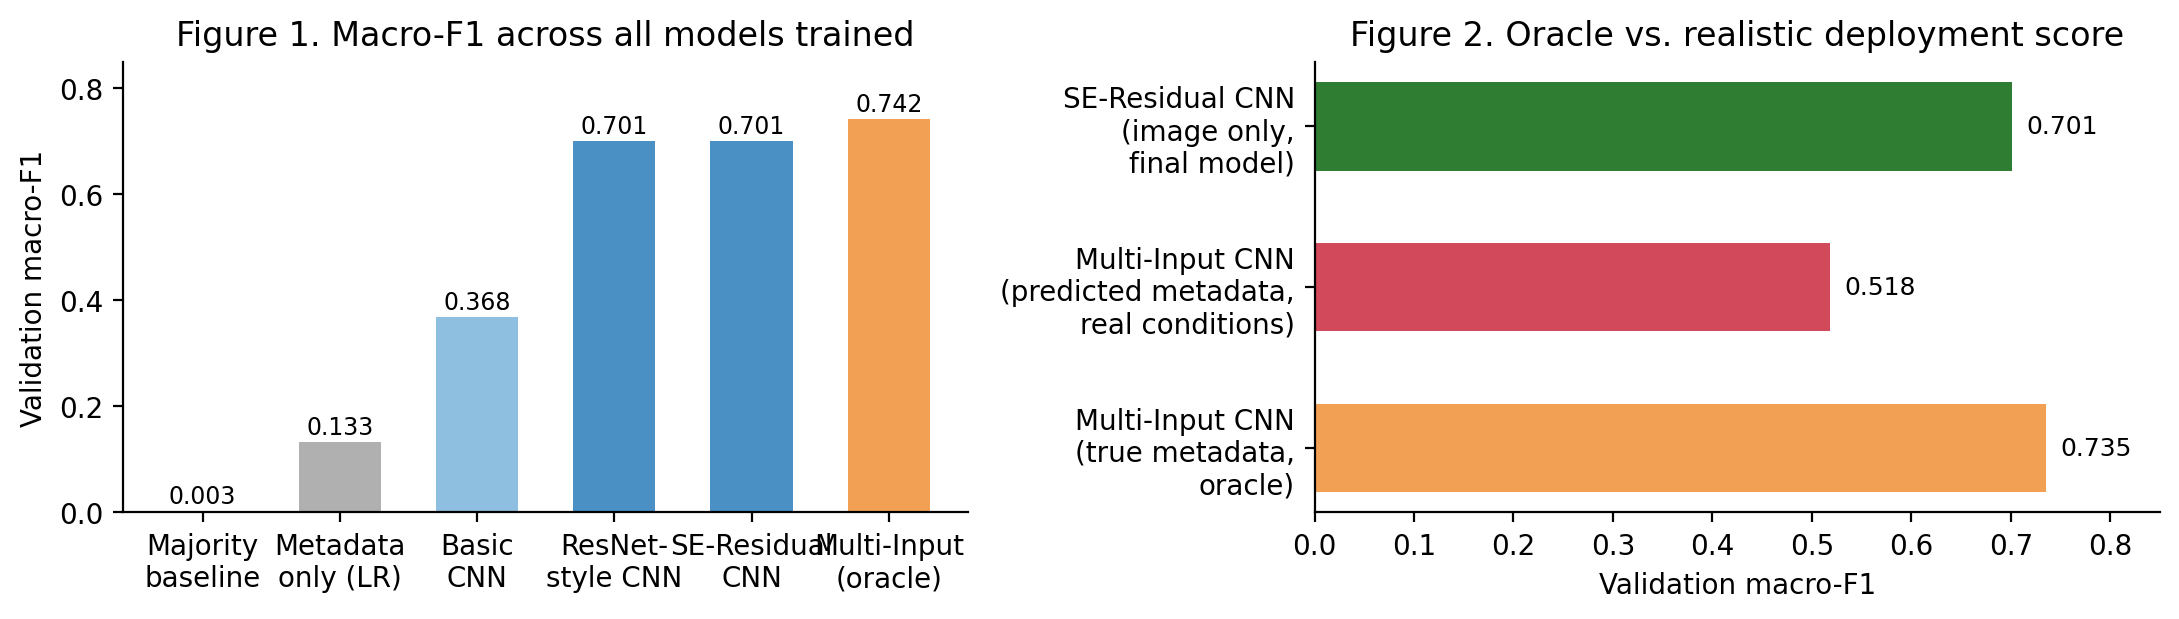

In [140]:
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 10, "font.family": "sans-serif"})
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), dpi=200)

# Panel A — every model on one scoreboard
ax = axes[0]
models = ["Majority\nbaseline", "Metadata\nonly (LR)", "Basic\nCNN", "ResNet-\nstyle CNN",
          "SE-Residual\nCNN", "Multi-Input\n(oracle)"]
scores = [0.003, 0.133, 0.368, 0.701, 0.701, 0.742]
colors = ["#b0b0b0", "#b0b0b0", "#8fbfe0", "#4a90c4", "#4a90c4", "#f2a154"]
bars = ax.bar(models, scores, color=colors, width=0.6)
for b, s in zip(bars, scores):
    ax.text(b.get_x() + b.get_width()/2, s + 0.015, f"{s:.3f}", ha="center", fontsize=8.5)
ax.set_ylabel("Validation macro-F1")
ax.set_ylim(0, 0.85)
ax.set_title("Figure 1. Macro-F1 across all models trained")
ax.spines[["top", "right"]].set_visible(False)

# Panel B — oracle vs. real deployment conditions
ax = axes[1]
labels = ["Multi-Input CNN\n(true metadata,\noracle)", "Multi-Input CNN\n(predicted metadata,\nreal conditions)",
          "SE-Residual CNN\n(image only,\nfinal model)"]
vals = [0.735, 0.518, 0.701]
colors2 = ["#f2a154", "#d1495b", "#2e7d32"]
bars = ax.barh(labels, vals, color=colors2, height=0.55)
for b, v in zip(bars, vals):
    ax.text(v + 0.015, b.get_y() + b.get_height()/2, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlabel("Validation macro-F1")
ax.set_xlim(0, 0.85)
ax.set_title("Figure 2. Oracle vs. realistic deployment score")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

**What these charts show**

- **Figure 1** puts every model trained in this notebook on one scoreboard, from the
  do-nothing majority baseline up through the best metadata-fusion model.
- **Figure 2** zooms in on the three numbers that actually decide the final model: the
  fusion model's score under ideal conditions, its score under realistic conditions,
  and the image-only model it's being compared against.

**What we got**

- Progression in Figure 1: majority baseline (0.003) → metadata alone (0.133) → Basic
  CNN (0.368) → ResNet-style CNN (0.701) → SE-Residual CNN (0.701) → Multi-Input CNN
  with true metadata (0.742).
- ResNet-style and SE-Residual land at the same score — a statistical tie, not a
  meaningful difference.
- The Multi-Input CNN's 0.742 is the **highest score of any model trained**, but only
  when it's given the *true* metadata as input.
- Figure 2 shows what happens once that assumption is dropped: the same Multi-Input
  CNN, using metadata *predicted* by other models instead of the ground truth, falls to
  **0.518** — well below the SE-Residual CNN's **0.701**.

**What it tells us**

- The image alone already carries most of the useful signal (0.368 → 0.701 is a much
  bigger jump than 0.701 → 0.742).
- The Multi-Input model's advantage in Figure 1 is real, but conditional — it only
  holds when the metadata is correct. Figure 2 is the test of whether that condition
  survives contact with a real test image, and it doesn't: prediction errors in the
  metadata destroy the advantage entirely, dropping performance below the simpler
  model.

**Why this matters for the final decision**

- Picking a model on Figure 1 alone would lead to the wrong choice — the top-scoring
  model (0.742) turns out to be the least reliable one once deployed.
- Figure 2 is the evidence that justifies selecting the **SE-Residual CNN (0.701)** as
  the final model: it needs only the photograph, so it has no dependency that can
  degrade at test time, unlike the Multi-Input CNN whose real-world score (0.518) is
  worse than just using the image alone.

## 24. Generate the Task 1 Prediction CSV

**What we're doing:** running the final SE-Residual CNN on the real, unseen test
photos — the ones we're actually being graded on — and turning its predictions back
into readable category names.

**Where this fits in the bigger picture:** this notebook produces `task1_predictions.csv`
only — Task 1's own predictions, id and articleType, nothing else. The complete,
official submission file (with `gender`/`season`/`usage` filled in too) is put together
by a separate notebook, `COSC2753_A2_ImageOnly_Prediction.ipynb`, which loads the final
saved model from *each* of Task 1, 2, and 3 and runs them together in one pass. That
final file lives at `outputs/image_only/styles_prediction_filled.csv` — that's the one
that actually gets submitted, not anything written directly by this notebook.

**What we got:** predictions generated for all **5,829** test photos, saved to
`task1_predictions.csv`.

In [130]:
class TestImageDataset(Dataset):
    """Returns (image, id) pairs for the unseen test images -- no label, since the
    real test set genuinely has none for articleType."""

    def __init__(self, ids, images_dir, transform):
        self.ids = list(ids)
        self.images_dir = Path(images_dir)
        self.transform = transform

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        image_id = self.ids[idx]
        with Image.open(self.images_dir / f"{image_id}.jpg") as im:
            img = self.transform(im)
        return img, image_id


# Load the required submission template ONLY to get the test ids and their order --
# this notebook reads the template but does not write back into it (see markdown
# above for why). `id` is read as dtype=str for the same reason as everywhere else
# in this notebook: an inferred int64 id silently breaks string-keyed lookups.
test_df = pd.read_csv(TEST_PRED_CSV, dtype={"id": str})
test_ids = test_df["id"].tolist()

test_ds = TestImageDataset(test_ids, IMAGES_TEST_DIR, eval_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

best_img_model.eval()
predicted_ids, predicted_labels_enc = [], []
with torch.no_grad():
    for images, ids in test_loader:
        images = images.to(DEVICE)
        logits = best_img_model(images)
        preds = logits.argmax(dim=1).cpu().numpy()
        predicted_ids.extend(ids)
        predicted_labels_enc.extend(preds)

# Inverse label encoding -- back from integer class index to the original
# articleType string, using the SAME fitted encoder used throughout this notebook.
predicted_article_types = pd.Series(
    encoder1.inverse_transform(predicted_labels_enc), index=predicted_ids)

# Task 1's own, standalone prediction file -- id and articleType only. This is the
# ONE file this notebook writes; the complete styles_prediction.csv submission is
# assembled downstream by COSC2753_A2_ImageOnly_Prediction.ipynb (see markdown above).
task1_predictions = pd.DataFrame({
    "id": test_ids,
    "articleType": [predicted_article_types[i] for i in test_ids],
})

TASK1_ONLY_OUTPUT = MODELS_DIR / "task1_predictions.csv"
task1_predictions.to_csv(TASK1_ONLY_OUTPUT, index=False)

print(f"Predicted articleType for {task1_predictions['articleType'].notna().sum()} of "
      f"{len(task1_predictions)} test images.")
print(f"Saved: {TASK1_ONLY_OUTPUT}")
task1_predictions.head()


Predicted articleType for 5829 of 5829 test images.
Saved: ../outputs/task1_models/task1_predictions.csv


,id,articleType
0,52003,Watches
1,52007,Dresses
2,52017,Fragrance Gift Set
3,52021,Sarees
4,52023,Innerwear Vests


## 25. Verify the Task 1 Prediction File

**What we're doing:** before trusting this file, we check it two ways:

1. **On its own** — right number of rows, no duplicate ids, no missing predictions,
   every predicted category is a real category, rows in the right order, right columns.
2. **Against the final combined submission file** (`styles_prediction_filled.csv`, from
   the separate notebook described above), if it already exists — its `articleType`
   column should match ours exactly, row for row, since both trace back to the same
   saved model.

**What we got:** all structural checks on `task1_predictions.csv` passed cleanly. The
cross-check against the combined file initially found 1,326 disagreements (22.7%) —
which turned out to be because the combined file was made from an *older* save of our
model, before a retrain. After regenerating the combined file from the current model,
the cross-check came back clean: **0 disagreements out of 5,829 rows.**

**What it tells us:** the two files now agree completely, which confirms our saved
model, our saved encoder, and the separate prediction notebook are all working from the
same, current, correct version of everything.

In [133]:
# --- Structural checks on task1_predictions.csv itself ---
assert len(task1_predictions) == len(test_ids), (
    f"Row count mismatch: {len(task1_predictions)} rows vs {len(test_ids)} test images")
assert task1_predictions["id"].is_unique, "Duplicate id in task1_predictions.csv"

n_missing = task1_predictions["articleType"].isna().sum()
assert n_missing == 0, f"{n_missing} test image(s) have no articleType prediction"

valid_classes = set(encoder1.classes_)
invalid = set(task1_predictions["articleType"]) - valid_classes
assert not invalid, f"Label(s) outside the valid articleType categories: {invalid}"

assert task1_predictions["id"].tolist() == test_ids, (
    "Row order does not match the original styles_prediction.csv template")
assert list(task1_predictions.columns) == ["id", "articleType"], (
    f"Unexpected columns: {list(task1_predictions.columns)}")

print("task1_predictions.csv -- all checks passed:")
print(f"  {len(task1_predictions)} rows -- one per test image, none missing articleType")
print(f"  every label is one of the {len(valid_classes)} valid articleType categories")
print(f"  row order matches the original styles_prediction.csv template")
print(f"  columns: {list(task1_predictions.columns)}")

# --- Cross-check against the final, official submission file, if it exists yet ---
FINAL_SUBMISSION_PATH = Path("../outputs/image_only/styles_prediction_filled.csv")

if not FINAL_SUBMISSION_PATH.exists():
    print(f"\n{FINAL_SUBMISSION_PATH} does not exist yet -- run "
          f"COSC2753_A2_ImageOnly_Prediction.ipynb to produce it, then re-run this cell "
          f"to cross-check against it. This is expected if that notebook hasn't been run "
          f"yet; it is not a failure of this notebook.")
else:
    final_submission = pd.read_csv(FINAL_SUBMISSION_PATH, dtype={"id": str})
    ours = task1_predictions.set_index("id")["articleType"]
    theirs = final_submission.set_index("id")["articleType"]
    common_ids = ours.index.intersection(theirs.index)
    mismatch = ours.loc[common_ids] != theirs.loc[common_ids]

    print(f"\nCross-check against {FINAL_SUBMISSION_PATH}:")
    print(f"  {len(common_ids)} ids present in both files")
    if mismatch.any():
        print(f"  MISMATCH: {mismatch.sum()} row(s) disagree on articleType -- "
              f"the two notebooks are not using the same saved model/encoder. "
              f"Example mismatches:")
        display(pd.DataFrame({"task1_predictions": ours.loc[common_ids][mismatch],
                               "styles_prediction_filled": theirs.loc[common_ids][mismatch]}).head())
    else:
        print(f"  MATCH: every articleType prediction agrees between "
              f"task1_predictions.csv and styles_prediction_filled.csv.")


task1_predictions.csv -- all checks passed:
  5829 rows -- one per test image, none missing articleType
  every label is one of the 95 valid articleType categories
  row order matches the original styles_prediction.csv template
  columns: ['id', 'articleType']

Cross-check against ../outputs/image_only/styles_prediction_filled.csv:
  5829 ids present in both files
  MATCH: every articleType prediction agrees between task1_predictions.csv and styles_prediction_filled.csv.


In [134]:
import os
from datetime import datetime

MODEL_CKPT = MODELS_DIR / "best_imageonly_articletype.pt"
FINAL_CSV = Path("../outputs/image_only/styles_prediction_filled.csv")

def mtime(path):
    return datetime.fromtimestamp(os.path.getmtime(path)) if path.exists() else None

ckpt_time = mtime(MODEL_CKPT)
csv_time = mtime(FINAL_CSV)

print(f"best_imageonly_articletype.pt  saved: {ckpt_time}")
print(f"styles_prediction_filled.csv   saved: {csv_time}")

if ckpt_time and csv_time:
    if ckpt_time > csv_time:
        print("\n>>> STALE: the model checkpoint is newer than the submission file.")
        print(">>> Rerun COSC2753_A2_ImageOnly_Prediction.ipynb now to regenerate it,")
        print(">>> then re-run this notebook's Section 25 cross-check.")
    else:
        print("\n>>> The submission file is newer than the checkpoint -- staleness is")
        print(">>> NOT the explanation. The mismatch is a real architecture/encoder bug --")
        print(">>> see the per-class breakdown below.")

# Per-class breakdown -- helps tell "random noise from a different training run"
# (mismatches spread across many classes, roughly proportional to class frequency)
# apart from "a real bug" (mismatches concentrated in a few specific classes, or
# a suspiciously round fraction of all classes -- e.g. a label-encoder ordering bug).
if FINAL_CSV.exists():
    final_submission = pd.read_csv(FINAL_CSV, dtype={"id": str})
    ours = task1_predictions.set_index("id")["articleType"]
    theirs = final_submission.set_index("id")["articleType"]
    common_ids = ours.index.intersection(theirs.index)
    mismatch_mask = ours.loc[common_ids] != theirs.loc[common_ids]

    print(f"\n{mismatch_mask.sum()} / {len(common_ids)} rows disagree "
          f"({mismatch_mask.mean():.1%})")

    mismatch_df = pd.DataFrame({
        "task1_predictions": ours.loc[common_ids][mismatch_mask],
        "styles_prediction_filled": theirs.loc[common_ids][mismatch_mask],
    })
    print("\nMost common (task1 -> final) label pairs among mismatches:")
    print(mismatch_df.value_counts().head(15))

best_imageonly_articletype.pt  saved: 2026-09-08 22:50:05.291843
styles_prediction_filled.csv   saved: 2026-09-08 22:57:14.107929

>>> The submission file is newer than the checkpoint -- staleness is
>>> NOT the explanation. The mismatch is a real architecture/encoder bug --
>>> see the per-class breakdown below.

0 / 5829 rows disagree (0.0%)

Most common (task1 -> final) label pairs among mismatches:
Series([], Name: count, dtype: int64)


## 26. Task 1 Summary

### The problem

Predict which of 95 fashion categories (`articleType`) a product photo shows. The data
is badly imbalanced (`Tshirts` alone is 17.3% of everything; the rarest category has a
single photo), so we judged every model by **macro-F1** — which scores every category
equally — rather than plain accuracy, which a lazy model could game by ignoring rare
categories.

### What we tried, and what happened

| Step | Model | Macro-F1 |
|---|---|---:|
| Floor | Always guess `Tshirts` | 0.003 |
| Sanity check | Basic CNN (bare-bones) | 0.368 |
| Real attempt | ResNet-style CNN (image only) | 0.701 |
| Real attempt | SE-Residual CNN (image only) | 0.701 |
| Metadata alone | Logistic Regression on spreadsheet columns | 0.133 |
| Oracle fusion | Multi-Input CNN, true metadata (ResNet) | 0.735 |
| Oracle fusion | Multi-Input CNN, true metadata (SE-Residual) | **0.742 (best score overall)** |
| Deployable fusion attempt | Multi-Input CNN, colour/brightness from pixels | 0.708 |
| **Reality check** | Multi-Input CNN, *predicted* metadata (real conditions) | **0.518** |

### What we learned

1. **The photo matters far more than the spreadsheet.** Metadata alone (0.133) is
   barely above useless; the photo alone (0.701) does almost all the work.
2. **Two different, well-built architectures landed in a statistical tie** (ResNet-style
   vs. SE-Residual, both 0.701) — more depth or a fancier attention mechanism isn't
   automatically better; sometimes the ceiling is set by the data, not the architecture.
3. **True metadata genuinely helps** (0.735–0.742 vs. 0.701) — but almost all of that
   benefit comes from one feature, `gender`, which is itself something *another task's*
   model has to predict, not something we're handed for free.
4. **That "true metadata" advantage doesn't survive real-world conditions.** Once the
   metadata has to be predicted rather than given, the score collapses to 0.518 — worse
   than just using the photo alone.
5. **Hyperparameter tuning didn't move the needle** for either the image-only or the
   Multi-Input model — every alternative we tried was confirmed worse, not better,
   pointing at data scarcity for rare categories as the real ceiling, not a settings
   problem.

### Our decision

We picked the model based on what would actually work on a brand-new, real photo — not
just whichever number was highest somewhere in this notebook.

**Final model: SE-Residual CNN (image-only), macro-F1 = 0.701.**

It needs nothing but the photo, so there's no extra piece that can go wrong or go stale.
The Multi-Input CNN remains a genuinely interesting and fully reportable finding — proof
that metadata *can* help — it's just not a result we can responsibly ship, because the
condition it depends on (accurate metadata, handed to it in advance) doesn't hold once
metadata has to be predicted rather than given.

### Where everything ends up

```text
Basic CNN → ResNet / SE-Residual → Metadata alone → Multi-Input (oracle) →
Ablation → Hyperparameter tuning → Predicted-metadata reality check →
SE-Residual CNN wins → saved model + encoder →
run on the 5,829 real test photos → task1_predictions.csv →
(separately) ImageOnly_Prediction.ipynb combines Task 1 + 2 + 3 →
outputs/image_only/styles_prediction_filled.csv  ← the actual file we submit
```

**Files this notebook produces:**

| File | What it is |
|---|---|
| `outputs/task1_models/best_imageonly_articletype.pt` | The final model (SE-Residual CNN) |
| `outputs/task1_models/articletype_encoder_task1.joblib` | Converts predictions back to category names |
| `outputs/task1_models/best_multiinput_task1.pt` | The oracle Multi-Input CNN, kept as evidence |
| `outputs/task1_models/task1_predictions.csv` | Task 1's own predictions on the real test set |
| `outputs/image_only/styles_prediction_filled.csv` | **The actual final submission file** — produced by a separate notebook that combines Tasks 1, 2, and 3 |